In [0]:
# Load US Flights 2023 data into Spark DataFrame
flights_df = spark.read.table("workspace.default.us_flights_2023")
geolocation_df = spark.read.table('workspace.default.airports_geolocation')
cancelled_df = spark.read.table('workspace.default.cancelled_diverted_2023')
weather_df = spark.read.table('workspace.default.weather_meteo_by_airport')

# Take a sample (first 5 rows) to verify loading
sample_df = flights_df.limit(5)
display(sample_df)

FlightDate,Day_Of_Week,Airline,Tail_Number,Dep_Airport,Dep_CityName,DepTime_label,Dep_Delay,Dep_Delay_Tag,Dep_Delay_Type,Arr_Airport,Arr_CityName,Arr_Delay,Arr_Delay_Type,Flight_Duration,Distance_type,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Manufacturer,Model,Aicraft_age
2023-12-04,1,United Air Lines Inc.,N37471,LAX,"Los Angeles, CA",Afternoon,3,1,Low <5min,DEN,"Denver, CO",-9,Low <5min,135,Short Haul >1500Mi,0,0,0,0,0,BOEING,737 NG,11
2023-12-04,1,United Air Lines Inc.,N47512,FLL,"Fort Lauderdale, FL",Morning,-5,0,Low <5min,ORD,"Chicago, IL",-19,Low <5min,189,Short Haul >1500Mi,0,0,0,0,0,BOEING,737 NG,5
2023-12-04,1,United Air Lines Inc.,N810UA,SFO,"San Francisco, CA",Morning,-11,0,Low <5min,RDM,"Bend/Redmond, OR",-16,Low <5min,93,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,26
2023-12-04,1,United Air Lines Inc.,N810UA,SBA,"Santa Barbara, CA",Morning,-6,0,Low <5min,SFO,"San Francisco, CA",-19,Low <5min,58,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,26
2023-12-04,1,United Air Lines Inc.,N897UA,SDF,"Louisville, KY",Afternoon,-4,0,Low <5min,DEN,"Denver, CO",-4,Low <5min,187,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,17


In [0]:
%sql
-- check count of each "time" (Can we use the time column to join with weather data? - NO)
-- SELECT COUNT(*) FROM weather_meteo_by_airport GROUP BY time

-- but Notice that every time" occurs exactly 364 times in the weather_meteo_by_airport table
-- SELECT COUNT(*) FROM weather_meteo_by_airport GROUP BY time HAVING COUNT(*) != '364'

-- Check if any other column can be used or pair of columns can be used to perform the join - Seem to only differ in airport_id
-- SELECT * FROM weather_meteo_by_airport WHERE time = '2023-01-01'

-- check if time-airport_id pairs are unique (they are)
SELECT time, airport_id, COUNT(*) AS pair_count FROM weather_meteo_by_airport GROUP BY time, airport_id HAVING COUNT(*) > 1


time,airport_id,pair_count


In [0]:
# flights_with_weather_df = flights_df.join(weather_df, on = flights_df['FlightDate'] == weather_df['time'], how = "left")
flights_with_weather_df = flights_df.join(weather_df, on=(flights_df["FlightDate"] == weather_df["time"]) & (flights_df["Dep_Airport"] == weather_df["airport_id"]), how="left")
display(flights_with_weather_df.limit(5))


FlightDate,Day_Of_Week,Airline,Tail_Number,Dep_Airport,Dep_CityName,DepTime_label,Dep_Delay,Dep_Delay_Tag,Dep_Delay_Type,Arr_Airport,Arr_CityName,Arr_Delay,Arr_Delay_Type,Flight_Duration,Distance_type,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Manufacturer,Model,Aicraft_age,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,airport_id
2023-12-04,1,United Air Lines Inc.,N37471,LAX,"Los Angeles, CA",Afternoon,3,1,Low <5min,DEN,"Denver, CO",-9,Low <5min,135,Short Haul >1500Mi,0,0,0,0,0,BOEING,737 NG,11,2023-12-04,15.3,10.6,22.2,0.0,0.0,317.0,6.5,1019.3,LAX
2023-12-04,1,United Air Lines Inc.,N47512,FLL,"Fort Lauderdale, FL",Morning,-5,0,Low <5min,ORD,"Chicago, IL",-19,Low <5min,189,Short Haul >1500Mi,0,0,0,0,0,BOEING,737 NG,5,2023-12-04,25.1,21.7,28.3,0.0,0.0,264.0,7.2,1016.2,FLL
2023-12-04,1,United Air Lines Inc.,N810UA,SFO,"San Francisco, CA",Morning,-11,0,Low <5min,RDM,"Bend/Redmond, OR",-16,Low <5min,93,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,26,2023-12-04,13.9,10.6,17.2,0.0,0.0,336.0,6.1,1024.1,SFO
2023-12-04,1,United Air Lines Inc.,N810UA,SBA,"Santa Barbara, CA",Morning,-6,0,Low <5min,SFO,"San Francisco, CA",-19,Low <5min,58,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,26,2023-12-04,13.9,6.7,22.2,0.0,0.0,340.0,4.0,1019.4,SBA
2023-12-04,1,United Air Lines Inc.,N897UA,SDF,"Louisville, KY",Afternoon,-4,0,Low <5min,DEN,"Denver, CO",-4,Low <5min,187,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,17,2023-12-04,5.6,2.2,10.6,4.6,0.0,355.0,6.8,1014.4,SDF


In [0]:
print("Shape before join:", (flights_df.count(), len(flights_df.columns)))
print("Shape after join:", (flights_with_weather_df.count(), len(flights_with_weather_df.columns)))
print("The Data has", flights_with_weather_df.select("Airline").distinct().count(), "unique Airlines") 


Shape before join: (6743404, 24)
Shape after join: (6743404, 34)
The Data has 15 unique Airlines


In [0]:
from pyspark.sql.functions import when

# Create new column 'Delayed (> 15 min)' (1 if Dep_Delay > 15, else 0)
flights_delayed_df = flights_with_weather_df.withColumn(
    "Delayed (> 15 min)",
    when(flights_with_weather_df["Arr_Delay"] > 15, 1).otherwise(0)
)
display(flights_delayed_df.limit(5))

FlightDate,Day_Of_Week,Airline,Tail_Number,Dep_Airport,Dep_CityName,DepTime_label,Dep_Delay,Dep_Delay_Tag,Dep_Delay_Type,Arr_Airport,Arr_CityName,Arr_Delay,Arr_Delay_Type,Flight_Duration,Distance_type,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Manufacturer,Model,Aicraft_age,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,airport_id,Delayed (> 15 min)
2023-12-04,1,United Air Lines Inc.,N37471,LAX,"Los Angeles, CA",Afternoon,3,1,Low <5min,DEN,"Denver, CO",-9,Low <5min,135,Short Haul >1500Mi,0,0,0,0,0,BOEING,737 NG,11,2023-12-04,15.3,10.6,22.2,0.0,0.0,317.0,6.5,1019.3,LAX,0
2023-12-04,1,United Air Lines Inc.,N47512,FLL,"Fort Lauderdale, FL",Morning,-5,0,Low <5min,ORD,"Chicago, IL",-19,Low <5min,189,Short Haul >1500Mi,0,0,0,0,0,BOEING,737 NG,5,2023-12-04,25.1,21.7,28.3,0.0,0.0,264.0,7.2,1016.2,FLL,0
2023-12-04,1,United Air Lines Inc.,N810UA,SFO,"San Francisco, CA",Morning,-11,0,Low <5min,RDM,"Bend/Redmond, OR",-16,Low <5min,93,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,26,2023-12-04,13.9,10.6,17.2,0.0,0.0,336.0,6.1,1024.1,SFO,0
2023-12-04,1,United Air Lines Inc.,N810UA,SBA,"Santa Barbara, CA",Morning,-6,0,Low <5min,SFO,"San Francisco, CA",-19,Low <5min,58,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,26,2023-12-04,13.9,6.7,22.2,0.0,0.0,340.0,4.0,1019.4,SBA,0
2023-12-04,1,United Air Lines Inc.,N897UA,SDF,"Louisville, KY",Afternoon,-4,0,Low <5min,DEN,"Denver, CO",-4,Low <5min,187,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,17,2023-12-04,5.6,2.2,10.6,4.6,0.0,355.0,6.8,1014.4,SDF,0


In [0]:
# Display summary statistics for numeric columns only
numeric_columns = [
    "Day_Of_Week", "Dep_Delay", "Arr_Delay", "Flight_Duration",
    "Delay_Carrier", "Delay_Weather", "Delay_NAS", "Delay_Security", "Delay_LastAircraft",
    "Aicraft_age", "tavg", "tmin", "tmax", "prcp", "snow", "wdir", "wspd", "pres",
    "Delayed (> 15 min)"
]

display(flights_delayed_df.select(numeric_columns).describe())

# How is there a flight duration of 0 minutes?

summary,Day_Of_Week,Dep_Delay,Arr_Delay,Flight_Duration,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Aicraft_age,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,Delayed (> 15 min)
count,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404
mean,3.9827932599025657,12.200986623373003,6.62715150983094,140.29777854033364,5.169803559152025,0.7428504950912032,2.566956984929273,0.030648764333265514,5.681107642371716,13.48062640174013,16.810826409021658,11.822923845315204,22.165465067746744,2.4378081455765304,3.2204973927114557,188.81902003795116,12.476340420965185,1015.729985435165,0.19866479896503308
stddev,2.001761815808881,55.079361141759804,57.07892145230851,72.87215749288374,36.45732361905642,14.353928078253157,15.004842221861123,1.6289230717178067,30.44646891849584,7.891494668265463,9.153797310963377,9.177309907630553,9.74868514264257,8.253368735721025,31.00108086015336,111.30652075147289,5.640855128779134,6.2422875399772355,0.3989951380969996
min,1,-99,-119,0,0,0,0,0,0,1,-39.1,-76.0,-35.0,0.0,0.0,0.0,0.0,968.6,0
max,7,4413,4405,795,3957,1860,1708,1460,3581,57,42.2,37.2,50.0,571.5,1780.0,360.0,59.4,1051.0,1


In [0]:
import pandas as pd

# Select key metrics for presentation (fewer columns for clarity)
presentation_columns = [
    "Dep_Delay", "Arr_Delay", "Flight_Duration",
    "Aicraft_age", "tavg", "prcp", "snow", "wspd"
]

# Get summary statistics and convert to pandas
summary_stats = flights_delayed_df.select(presentation_columns).toPandas().describe()

# Round to 2 decimal places for cleaner presentation
summary_stats = summary_stats.round(2)

# Transpose for better readability in presentations (variables as rows)
summary_transposed = summary_stats.T

# Reset index to make variable names an actual column
summary_transposed = summary_transposed.reset_index()
summary_transposed = summary_transposed.rename(columns={'index': 'Variable'})

# Display with cleaner formatting
display(summary_transposed)

Variable,count,mean,std,min,25%,50%,75%,max
Dep_Delay,6743404.0,12.2,55.08,-99.0,-5.0,-2.0,9.0,4413.0
Arr_Delay,6743404.0,6.63,57.08,-119.0,-15.0,-6.0,9.0,4405.0
Flight_Duration,6743404.0,140.3,72.87,0.0,87.0,124.0,171.0,795.0
Aicraft_age,6743404.0,13.48,7.89,1.0,7.0,12.0,20.0,57.0
tavg,6743404.0,16.81,9.15,-39.1,10.4,17.8,23.9,42.2
prcp,6743404.0,2.44,8.25,0.0,0.0,0.0,0.5,571.5
snow,6743404.0,3.22,31.0,0.0,0.0,0.0,0.0,1780.0
wspd,6743404.0,12.48,5.64,0.0,8.4,11.5,15.5,59.4


In [0]:
# Filter for flights with 0 minute duration
zero_duration_flights = flights_delayed_df.filter(flights_delayed_df["Flight_Duration"] == 0)

print(f"Number of flights with 0 duration: {zero_duration_flights.count()}")
display(zero_duration_flights.limit(20))

Number of flights with 0 duration: 1


FlightDate,Day_Of_Week,Airline,Tail_Number,Dep_Airport,Dep_CityName,DepTime_label,Dep_Delay,Dep_Delay_Tag,Dep_Delay_Type,Arr_Airport,Arr_CityName,Arr_Delay,Arr_Delay_Type,Flight_Duration,Distance_type,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Manufacturer,Model,Aicraft_age,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,airport_id,Delayed (> 15 min)
2023-05-21,7,Republic Airways,N231JQ,LGA,"New York, NY",Afternoon,37,1,Medium >15min,BNA,"Nashville, TN",0,Low <5min,0,Short Haul >1500Mi,0,0,0,0,0,EMBRAER,170/175,16,2023-05-21,17.5,13.0,21.0,0.3,0.0,317.0,10.8,1014.3,LGA,0


In [0]:
# Databricks manages the connection
# spark.stop()

# Cleaning

In [0]:
print("All columns in the joined DataFrame:")
for i, c in enumerate(flights_with_weather_df.columns):
    print(f"{i}: {c}")

All columns in the joined DataFrame:
0: FlightDate
1: Day_Of_Week
2: Airline
3: Tail_Number
4: Dep_Airport
5: Dep_CityName
6: DepTime_label
7: Dep_Delay
8: Dep_Delay_Tag
9: Dep_Delay_Type
10: Arr_Airport
11: Arr_CityName
12: Arr_Delay
13: Arr_Delay_Type
14: Flight_Duration
15: Distance_type
16: Delay_Carrier
17: Delay_Weather
18: Delay_NAS
19: Delay_Security
20: Delay_LastAircraft
21: Manufacturer
22: Model
23: Aicraft_age
24: time
25: tavg
26: tmin
27: tmax
28: prcp
29: snow
30: wdir
31: wspd
32: pres
33: airport_id


In [0]:
from pyspark.sql.functions import col, when, isnan, count, mean as _mean
from pyspark.sql.types import IntegerType, DoubleType

# Drop duplicate columns from join
# Remove redundant columns created during the weather join
cleaned_df = flights_delayed_df.drop("time", "airport_id")

print(f"Number of columns after dropping duplicates: {len(cleaned_df.columns)}")
print("Remaining columns:", cleaned_df.columns)

Number of columns after dropping duplicates: 33
Remaining columns: ['FlightDate', 'Day_Of_Week', 'Airline', 'Tail_Number', 'Dep_Airport', 'Dep_CityName', 'DepTime_label', 'Dep_Delay', 'Dep_Delay_Tag', 'Dep_Delay_Type', 'Arr_Airport', 'Arr_CityName', 'Arr_Delay', 'Arr_Delay_Type', 'Flight_Duration', 'Distance_type', 'Delay_Carrier', 'Delay_Weather', 'Delay_NAS', 'Delay_Security', 'Delay_LastAircraft', 'Manufacturer', 'Model', 'Aicraft_age', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'pres', 'Delayed (> 15 min)']


In [0]:
# Remove rows with Flight_Duration = 0
# Inspect abnormal flights (duration <= 0)
print("\n=== Checking Flight_Duration outliers ===")
flights_with_weather_df.filter(col("Flight_Duration") <= 0).show(5)

zero_duration_count = cleaned_df.filter(col("Flight_Duration") <= 0).count()
print(f"Number of rows with Flight_Duration <= 0: {zero_duration_count}")

# Remove invalid flight durations
before = cleaned_df.count()
cleaned_df = cleaned_df.filter(
    (col("Flight_Duration") > 0) & col("Flight_Duration").isNotNull()
)
print(f"Rows removed: {before - cleaned_df.count()}")


=== Checking Flight_Duration outliers ===
+----------+-----------+----------------+-----------+-----------+------------+-------------+---------+-------------+--------------+-----------+-------------+---------+--------------+---------------+------------------+-------------+-------------+---------+--------------+------------------+------------+-------+-----------+----------+----+----+----+----+----+-----+----+------+----------+
|FlightDate|Day_Of_Week|         Airline|Tail_Number|Dep_Airport|Dep_CityName|DepTime_label|Dep_Delay|Dep_Delay_Tag|Dep_Delay_Type|Arr_Airport| Arr_CityName|Arr_Delay|Arr_Delay_Type|Flight_Duration|     Distance_type|Delay_Carrier|Delay_Weather|Delay_NAS|Delay_Security|Delay_LastAircraft|Manufacturer|  Model|Aicraft_age|      time|tavg|tmin|tmax|prcp|snow| wdir|wspd|  pres|airport_id|
+----------+-----------+----------------+-----------+-----------+------------+-------------+---------+-------------+--------------+-----------+-------------+---------+--------------

In [0]:
# Drop rows with missing target values
cleaned_df = cleaned_df.filter(
    col("Dep_Delay").isNotNull() & col("Arr_Delay").isNotNull()
)

# Remove extreme outliers in delay columns
# Cap unrealistic delays (e.g., more than 24 hours)
cleaned_df = cleaned_df.filter(
    (col("Arr_Delay") < 1440) & (col("Arr_Delay") > -180) &
    (col("Dep_Delay") < 1440) & (col("Dep_Delay") > -180)
)

# Fill missing values in delay cause columns with 0
# If there was no delay, these columns are NULL -> fill with 0
delay_cause_cols = ["Delay_Carrier", "Delay_Weather", "Delay_NAS",
                    "Delay_Security", "Delay_LastAircraft"]

for c in delay_cause_cols:
    cleaned_df = cleaned_df.withColumn(
        c, when(col(c).isNull(), 0).otherwise(col(c))
    )

# Handle missing values in weather columns
# Snow and precipitation: NULL means no snow/rain -> fill with 0
cleaned_df = cleaned_df.withColumn("snow", when(col("snow").isNull(), 0).otherwise(col("snow")))
cleaned_df = cleaned_df.withColumn("prcp", when(col("prcp").isNull(), 0).otherwise(col("prcp")))

# Temperature, pressure, wind: fill with mean
weather_numeric = ["tavg", "tmin", "tmax", "wdir", "wspd", "pres"]

for c in weather_numeric:
    mean_val = cleaned_df.select(_mean(col(c))).collect()[0][0]
    if mean_val is not None:
        cleaned_df = cleaned_df.withColumn(
            c, when(col(c).isNull(), mean_val).otherwise(col(c))
        )

# Handle Aircraft_age (note: typo 'Aicraft_age')
age_mean = cleaned_df.select(_mean(col("Aicraft_age"))).collect()[0][0]
cleaned_df = cleaned_df.withColumn(
    "Aicraft_age",
    when(col("Aicraft_age").isNull() | (col("Aicraft_age") < 0), age_mean)
    .otherwise(col("Aicraft_age"))
)

# Rename Aicraft_age to Aircraft_age to fix typo
cleaned_df = cleaned_df.withColumnRenamed("Aicraft_age", "Aircraft_age")

# Drop duplicate rows
before = cleaned_df.count()
cleaned_df = cleaned_df.dropDuplicates()
print(f"Duplicate rows removed: {before - cleaned_df.count()}")

# Remove redundant columns
cleaned_df = cleaned_df.drop("Dep_Delay_Tag", "Dep_Delay_Type", "Dep_CityName", "Arr_Delay_Type", "Arr_CityName", "Distance_type")

Duplicate rows removed: 31


In [0]:

# Final check
print(f"\n✅ Final shape: ({cleaned_df.count()}, {len(cleaned_df.columns)})")
print(f"✅ Final columns: {cleaned_df.columns}")

# Final missing value check
missing_check = cleaned_df.select([
    count(when(col(c).isNull(), c)).alias(c) for c in cleaned_df.columns
])
print("\n=== Final missing values ===")
missing_check.show(vertical=True, truncate=False)

display(cleaned_df.limit(5))


✅ Final shape: (6742824, 27)
✅ Final columns: ['FlightDate', 'Day_Of_Week', 'Airline', 'Tail_Number', 'Dep_Airport', 'DepTime_label', 'Dep_Delay', 'Arr_Airport', 'Arr_Delay', 'Flight_Duration', 'Delay_Carrier', 'Delay_Weather', 'Delay_NAS', 'Delay_Security', 'Delay_LastAircraft', 'Manufacturer', 'Model', 'Aircraft_age', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'pres', 'Delayed (> 15 min)']

=== Final missing values ===
-RECORD 0-----------------
 FlightDate         | 0   
 Day_Of_Week        | 0   
 Airline            | 0   
 Tail_Number        | 0   
 Dep_Airport        | 0   
 DepTime_label      | 0   
 Dep_Delay          | 0   
 Arr_Airport        | 0   
 Arr_Delay          | 0   
 Flight_Duration    | 0   
 Delay_Carrier      | 0   
 Delay_Weather      | 0   
 Delay_NAS          | 0   
 Delay_Security     | 0   
 Delay_LastAircraft | 0   
 Manufacturer       | 0   
 Model              | 0   
 Aircraft_age       | 0   
 tavg               | 0   
 tmin               |

FlightDate,Day_Of_Week,Airline,Tail_Number,Dep_Airport,DepTime_label,Dep_Delay,Arr_Airport,Arr_Delay,Flight_Duration,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Manufacturer,Model,Aircraft_age,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,Delayed (> 15 min)
2023-12-04,1,United Air Lines Inc.,N77530,PHL,Evening,-7,ORD,-28,124,0,0,0,0,0,BOEING,737 NG,13.0,9.1,3.3,11.1,0.0,0.0,267.0,13.7,1010.4,0
2023-12-04,1,United Air Lines Inc.,N16701,CLE,Morning,-5,EWR,-13,85,0,0,0,0,0,BOEING,737 NG,26.0,4.6,2.8,5.6,0.5,0.0,256.0,14.4,1014.2,0
2023-12-04,1,United Air Lines Inc.,N801UA,ORD,Evening,0,SYR,-11,100,0,0,0,0,0,AIRBUS,A319,27.0,2.8,0.0,5.0,0.0,0.0,283.0,9.7,1015.1,0
2023-12-04,1,United Air Lines Inc.,N817UA,ATL,Morning,-7,DEN,-2,214,0,0,0,0,0,AIRBUS,A319,26.0,11.4,5.6,19.4,0.0,0.0,292.0,9.7,1014.5,0
2023-12-03,7,United Air Lines Inc.,N817UA,ORD,Morning,-5,LGA,4,139,0,0,0,0,0,AIRBUS,A319,26.0,4.1,2.2,4.4,7.1,0.0,274.0,11.5,1008.2,0


In [0]:
from pyspark.sql.functions import month, dayofmonth, col, concat_ws, when

# Temporal features from FlightDate
cleaned_df = cleaned_df.withColumn("Month", month(col("FlightDate")))
cleaned_df = cleaned_df.withColumn("DayOfMonth", dayofmonth(col("FlightDate")))  # 1-31

# Time of day numeric encoding
time_of_day_map = {"Morning": 0, "Afternoon": 1, "Evening": 2, "Night": 3}
cleaned_df = cleaned_df.withColumn(
    "DepTimeOfDay_numeric",
    when(col("DepTime_label") == "Morning", 0)
    .when(col("DepTime_label") == "Afternoon", 1)
    .when(col("DepTime_label") == "Evening", 2)
    .when(col("DepTime_label") == "Night", 3)
    .otherwise(None)
)

# Drop FlightDate and DepTime_label
cleaned_df = cleaned_df.drop("FlightDate")
cleaned_df = cleaned_df.drop("DepTime_label")

display(cleaned_df.limit(5))

Day_Of_Week,Airline,Tail_Number,Dep_Airport,Dep_Delay,Arr_Airport,Arr_Delay,Flight_Duration,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Manufacturer,Model,Aircraft_age,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,Delayed (> 15 min),Month,DayOfMonth,DepTimeOfDay_numeric
1,United Air Lines Inc.,N77530,PHL,-7,ORD,-28,124,0,0,0,0,0,BOEING,737 NG,13.0,9.1,3.3,11.1,0.0,0.0,267.0,13.7,1010.4,0,12,4,2
1,United Air Lines Inc.,N16701,CLE,-5,EWR,-13,85,0,0,0,0,0,BOEING,737 NG,26.0,4.6,2.8,5.6,0.5,0.0,256.0,14.4,1014.2,0,12,4,0
1,United Air Lines Inc.,N801UA,ORD,0,SYR,-11,100,0,0,0,0,0,AIRBUS,A319,27.0,2.8,0.0,5.0,0.0,0.0,283.0,9.7,1015.1,0,12,4,2
1,United Air Lines Inc.,N817UA,ATL,-7,DEN,-2,214,0,0,0,0,0,AIRBUS,A319,26.0,11.4,5.6,19.4,0.0,0.0,292.0,9.7,1014.5,0,12,4,0
7,United Air Lines Inc.,N817UA,ORD,-5,LGA,4,139,0,0,0,0,0,AIRBUS,A319,26.0,4.1,2.2,4.4,7.1,0.0,274.0,11.5,1008.2,0,12,3,0


Computing correlations for 22 numeric features...
Features: ['Day_Of_Week', 'Dep_Delay', 'Arr_Delay', 'Flight_Duration', 'Delay_Carrier', 'Delay_Weather', 'Delay_NAS', 'Delay_Security', 'Delay_LastAircraft', 'Aircraft_age', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'pres', 'Delayed (> 15 min)', 'Month', 'DayOfMonth', 'DepTimeOfDay_numeric']


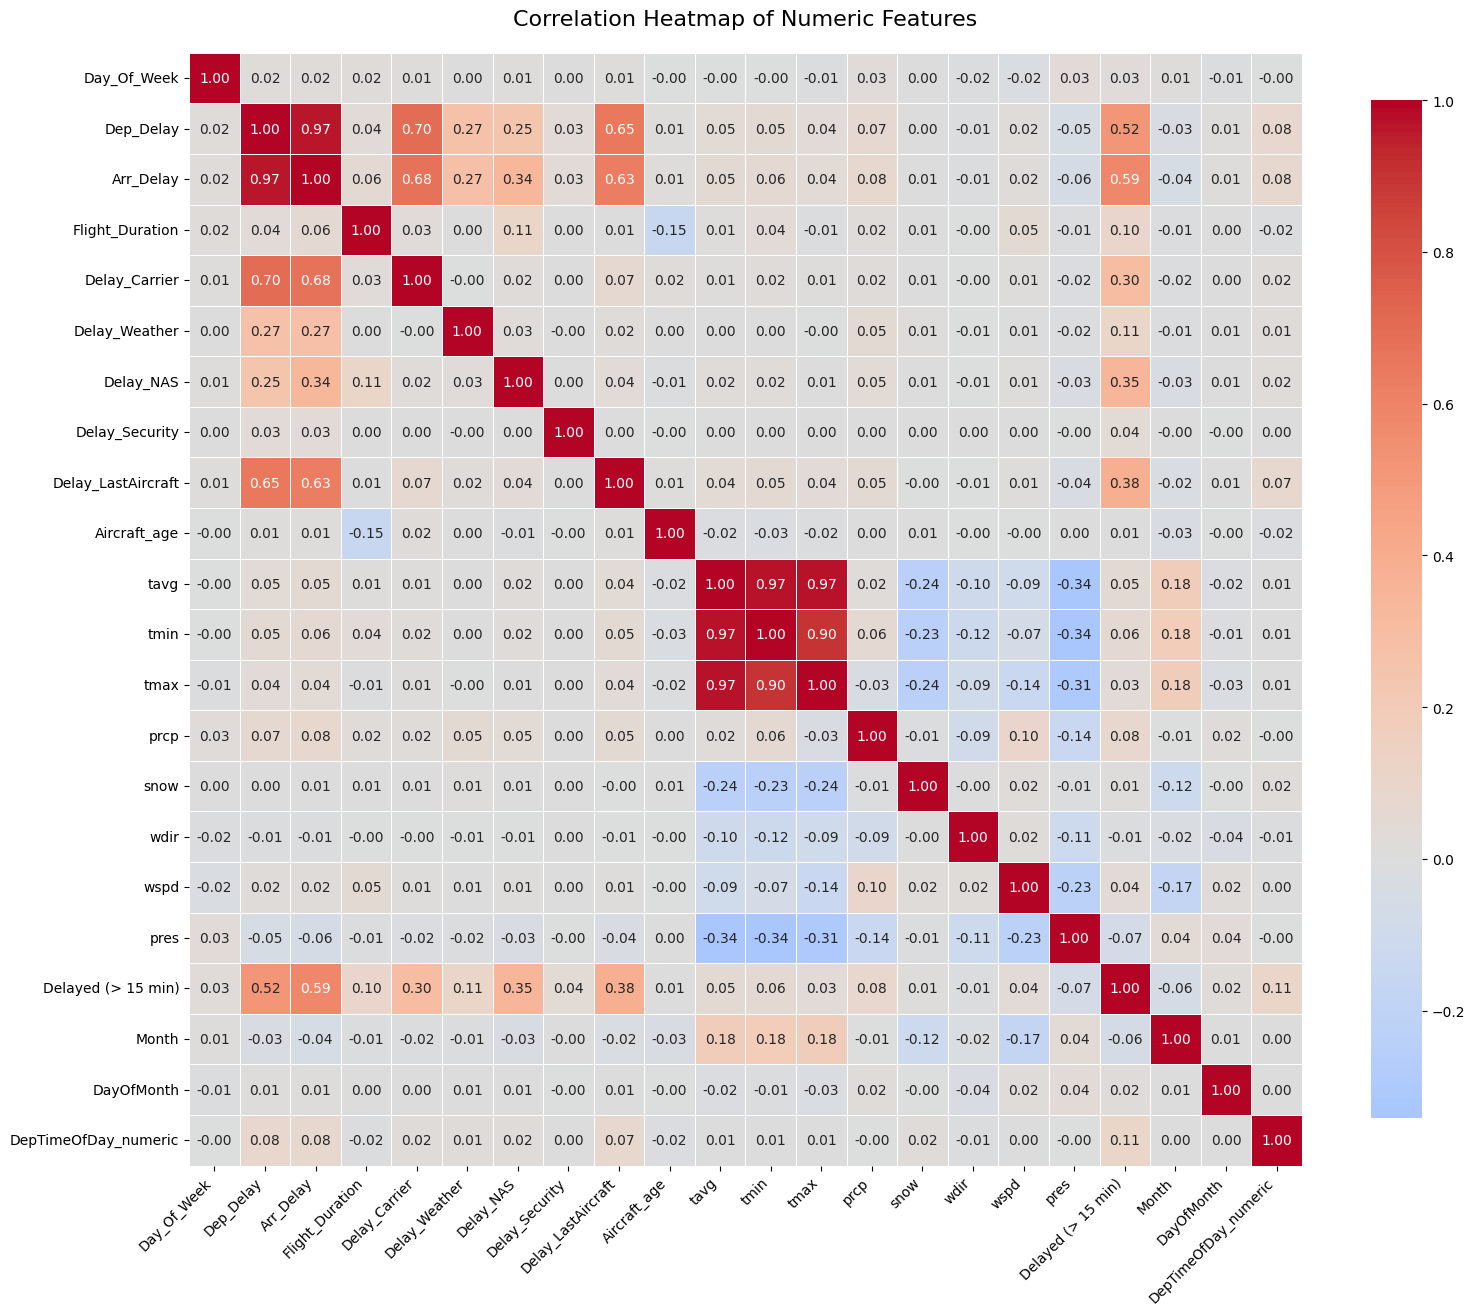


✅ Correlation heatmap complete!


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql.types import NumericType

# Select only numeric columns for correlation
numeric_cols = [field.name for field in cleaned_df.schema.fields 
                if isinstance(field.dataType, NumericType)]

print(f"Computing correlations for {len(numeric_cols)} numeric features...")
print(f"Features: {numeric_cols}")

# Sample data and convert to pandas for correlation computation
# Using a sample for performance - adjust sample size as needed
corr_data = cleaned_df.select(numeric_cols).sample(fraction=0.1, seed=42).toPandas()

# Compute correlation matrix
corr_matrix = corr_data.corr()

# Create heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numeric Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✅ Correlation heatmap complete!")

In [0]:
# Remove highly correlated and redundant/unnecessary features
cols_to_remove = ["tmin", "tmax", "Tail_Number", "Manufacturer"]

print(f"Removing {len(cols_to_remove)} features:")
for col in cols_to_remove:
    print(f"  - {col}")

# Create ML-ready dataframe
cleaned_df = cleaned_df.drop(*cols_to_remove)

# Display sample
display(cleaned_df.limit(5))

Removing 4 features:
  - tmin
  - tmax
  - Tail_Number
  - Manufacturer


Day_Of_Week,Airline,Dep_Airport,Dep_Delay,Arr_Airport,Arr_Delay,Flight_Duration,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Model,Aircraft_age,tavg,prcp,snow,wdir,wspd,pres,Delayed (> 15 min),Month,DayOfMonth,DepTimeOfDay_numeric
1,United Air Lines Inc.,PHL,-7,ORD,-28,124,0,0,0,0,0,737 NG,13.0,9.1,0.0,0.0,267.0,13.7,1010.4,0,12,4,2
1,United Air Lines Inc.,CLE,-5,EWR,-13,85,0,0,0,0,0,737 NG,26.0,4.6,0.5,0.0,256.0,14.4,1014.2,0,12,4,0
1,United Air Lines Inc.,ORD,0,SYR,-11,100,0,0,0,0,0,A319,27.0,2.8,0.0,0.0,283.0,9.7,1015.1,0,12,4,2
1,United Air Lines Inc.,ATL,-7,DEN,-2,214,0,0,0,0,0,A319,26.0,11.4,0.0,0.0,292.0,9.7,1014.5,0,12,4,0
7,United Air Lines Inc.,ORD,-5,LGA,4,139,0,0,0,0,0,A319,26.0,4.1,7.1,0.0,274.0,11.5,1008.2,0,12,3,0


In [0]:
from pyspark.sql.types import StringType

# Check what categorical features we have
categorical_cols = [field.name for field in cleaned_df.schema.fields 
                   if isinstance(field.dataType, StringType)]

print(f"Current categorical features ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")

Current categorical features (4):
  - Airline
  - Dep_Airport
  - Arr_Airport
  - Model


In [0]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

# Get current categorical columns
categorical_cols = [field.name for field in cleaned_df.schema.fields 
                   if isinstance(field.dataType, StringType)]

print(f"Encoding {len(categorical_cols)} categorical features...\n")

# Create StringIndexer stages (convert strings to numeric indices)
indexers = [
    StringIndexer(inputCol=col, outputCol=col + "_indexed", handleInvalid="keep")
    for col in categorical_cols
]

# Create OneHotEncoder stages (convert indices to binary vectors)
encoders = [
    OneHotEncoder(inputCol=col + "_indexed", outputCol=col + "_encoded")
    for col in categorical_cols
]

# Combine all stages into a pipeline
pipeline = Pipeline(stages=indexers + encoders)

# Fit and transform the data
print("Fitting encoding pipeline...")
encoding_model = pipeline.fit(cleaned_df)
print("Transforming data...")
cleaned_df = encoding_model.transform(cleaned_df)

# Drop original categorical columns and indexed columns (keep only encoded)
columns_to_drop = categorical_cols + [col + "_indexed" for col in categorical_cols]
cleaned_df = cleaned_df.drop(*columns_to_drop)

print(f"\n✅ Encoding complete!")
print(f"Final number of columns: {len(cleaned_df.columns)}")
print(f"\nNew encoded columns added:")
for col in categorical_cols:
    print(f"  - {col}_encoded")

# Display sample
display(cleaned_df.limit(3))

Encoding 4 categorical features...

Fitting encoding pipeline...
Transforming data...

✅ Encoding complete!
Final number of columns: 24

New encoded columns added:
  - Airline_encoded
  - Dep_Airport_encoded
  - Arr_Airport_encoded
  - Model_encoded


Day_Of_Week,Dep_Delay,Arr_Delay,Flight_Duration,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Aircraft_age,tavg,prcp,snow,wdir,wspd,pres,Delayed (> 15 min),Month,DayOfMonth,DepTimeOfDay_numeric,Airline_encoded,Dep_Airport_encoded,Arr_Airport_encoded,Model_encoded
1,-7,-28,124,0,0,0,0,0,13.0,9.1,0.0,0.0,267.0,13.7,1010.4,0,12,4,2,"{""type"":""0"",""size"":""15"",""indices"":[""3""],""values"":[""1.0""]}","{""type"":""0"",""size"":""350"",""indices"":[""25""],""values"":[""1.0""]}","{""type"":""0"",""size"":""350"",""indices"":[""3""],""values"":[""1.0""]}","{""type"":""0"",""size"":""21"",""indices"":[""0""],""values"":[""1.0""]}"
1,-5,-13,85,0,0,0,0,0,26.0,4.6,0.5,0.0,256.0,14.4,1014.2,0,12,4,0,"{""type"":""0"",""size"":""15"",""indices"":[""3""],""values"":[""1.0""]}","{""type"":""0"",""size"":""350"",""indices"":[""44""],""values"":[""1.0""]}","{""type"":""0"",""size"":""350"",""indices"":[""13""],""values"":[""1.0""]}","{""type"":""0"",""size"":""21"",""indices"":[""0""],""values"":[""1.0""]}"
1,0,-11,100,0,0,0,0,0,27.0,2.8,0.0,0.0,283.0,9.7,1015.1,0,12,4,2,"{""type"":""0"",""size"":""15"",""indices"":[""3""],""values"":[""1.0""]}","{""type"":""0"",""size"":""350"",""indices"":[""3""],""values"":[""1.0""]}","{""type"":""0"",""size"":""350"",""indices"":[""86""],""values"":[""1.0""]}","{""type"":""0"",""size"":""21"",""indices"":[""5""],""values"":[""1.0""]}"


In [0]:
# Create 80/20 train/test split on the full dataframe
# This split will be used for both classification and regression tasks

# Set seed for reproducibility
seed = 42

# Split the data
train_df, test_df = cleaned_df.randomSplit([0.8, 0.2], seed=seed)

# Display split sizes
train_count = train_df.count()
test_count = test_df.count()
total_count = train_count + test_count

print(f"Total rows: {total_count:,}")
print(f"Train set: {train_count:,} ({train_count/total_count*100:.1f}%)")
print(f"Test set: {test_count:,} ({test_count/total_count*100:.1f}%)")

Total rows: 6,742,873
Train set: 5,394,421 (80.0%)
Test set: 1,348,452 (20.0%)


In [0]:
train_df.printSchema()

root
 |-- Day_Of_Week: long (nullable = true)
 |-- Dep_Delay: long (nullable = true)
 |-- Arr_Delay: long (nullable = true)
 |-- Flight_Duration: long (nullable = true)
 |-- Delay_Carrier: long (nullable = true)
 |-- Delay_Weather: long (nullable = true)
 |-- Delay_NAS: long (nullable = true)
 |-- Delay_Security: long (nullable = true)
 |-- Delay_LastAircraft: long (nullable = true)
 |-- Aircraft_age: double (nullable = true)
 |-- tavg: double (nullable = true)
 |-- prcp: double (nullable = true)
 |-- snow: double (nullable = true)
 |-- wdir: double (nullable = true)
 |-- wspd: double (nullable = true)
 |-- pres: double (nullable = true)
 |-- Delayed (> 15 min): integer (nullable = false)
 |-- Month: integer (nullable = true)
 |-- DayOfMonth: integer (nullable = true)
 |-- DepTimeOfDay_numeric: integer (nullable = true)
 |-- Airline_encoded: vectorudt (nullable = true)
 |-- Dep_Airport_encoded: vectorudt (nullable = true)
 |-- Arr_Airport_encoded: vectorudt (nullable = true)
 |-- Model

# Regression

In [0]:
from pyspark.sql.types import StringType, NumericType
from pyspark.sql.functions import col

# Define target column for regression
target_col = "Arr_Delay"

print(f"=== Regression Feature Sets (Delayed Flights Only) ===")
print(f"Target: {target_col}")

# Filter for delayed flights only (Delayed >= 15 min)
train_delayed = train_df.filter(col("Delayed (> 15 min)") == 1)
test_delayed = test_df.filter(col("Delayed (> 15 min)") == 1)

print(f"\nFiltered to delayed flights only:")
print(f"  Train: {train_delayed.count():,} delayed flights (from {train_df.count():,} total)")
print(f"  Test: {test_delayed.count():,} delayed flights (from {test_df.count():,} total)")

# Columns to exclude from features
exclude_cols = [
    target_col,  # Regression target
    "Delayed (> 15 min)"  # Classification target (not needed for regression)
]

# Get all feature columns (everything except targets)
feature_cols = [col for col in train_delayed.columns if col not in exclude_cols]
print(feature_cols)
print(f"\nTotal features: {len(feature_cols)}")

# Create X and y for train set
X_train_reg = train_delayed.select(feature_cols)
y_train_reg = train_delayed.select(target_col)

# Create X and y for test set
X_test_reg = test_delayed.select(feature_cols)
y_test_reg = test_delayed.select(target_col)

print(f"\n=== Train Set ===")
print(f"X_train_reg shape: ({X_train_reg.count()}, {len(X_train_reg.columns)})")
print(f"y_train_reg shape: ({y_train_reg.count()}, 1)")

print(f"\n=== Test Set ===")
print(f"X_test_reg shape: ({X_test_reg.count()}, {len(X_test_reg.columns)})")
print(f"y_test_reg shape: ({y_test_reg.count()}, 1)")

=== Regression Feature Sets (Delayed Flights Only) ===
Target: Arr_Delay

Filtered to delayed flights only:
  Train: 1,071,316 delayed flights (from 5,394,372 total)
  Test: 267,812 delayed flights (from 1,348,452 total)
['Day_Of_Week', 'Dep_Delay', 'Flight_Duration', 'Delay_Carrier', 'Delay_Weather', 'Delay_NAS', 'Delay_Security', 'Delay_LastAircraft', 'Aircraft_age', 'tavg', 'prcp', 'snow', 'wdir', 'wspd', 'pres', 'Month', 'DayOfMonth', 'DepTimeOfDay_numeric', 'Airline_encoded', 'Dep_Airport_encoded', 'Arr_Airport_encoded', 'Model_encoded']

Total features: 22

=== Train Set ===
X_train_reg shape: (1071316, 22)
y_train_reg shape: (1071316, 1)

=== Test Set ===
X_test_reg shape: (267812, 22)
y_test_reg shape: (267812, 1)


In [0]:
from pyspark.ml.feature import VectorAssembler
print("=== Preparing Features for Decision Tree Regression ===")

# Get feature column names (all columns except targets)
feature_cols = [col for col in train_delayed.columns if col not in ["Arr_Delay", "Delayed (> 15 min)"]]

print(f"Number of features: {len(feature_cols)}")
print(f"\nAssembling feature vector...")

# Create VectorAssembler to combine all features into a single vector column
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# Transform train and test data using FILTERED datasets (delayed flights only)
train_data = assembler.transform(train_delayed.withColumnRenamed("Arr_Delay", "label"))
test_data = assembler.transform(test_delayed.withColumnRenamed("Arr_Delay", "label"))

=== Preparing Features for Decision Tree Regression ===
Number of features: 22

Assembling feature vector...


In [0]:
from pyspark.ml.feature import VectorAssembler

print("=== Removing Delay Breakdown Features to Fix Data Leakage ===")

# These features provide breakdown of departure delay by cause
# They give the model nearly perfect information about the delay
leakage_features = [
    "Delay_Carrier",
    "Delay_Weather", 
    "Delay_NAS",
    "Delay_Security",
    "Delay_LastAircraft",
    "Dep_Delay"
]

print(f"\nRemoving {len(leakage_features)} leakage features:")
for feat in leakage_features:
    print(f"  - {feat}")

# Drop leakage features from delayed datasets
train_delayed_clean = train_delayed.drop(*leakage_features)
test_delayed_clean = test_delayed.drop(*leakage_features)

# Get new feature column list (excluding targets and leakage features)
feature_cols_clean = [col for col in train_delayed_clean.columns 
                      if col not in ["Arr_Delay", "Delayed (> 15 min)"]]

print(f"\nFeatures after removal: {len(feature_cols_clean)} (was {len(feature_cols_clean) + len(leakage_features)})")

# Re-assemble feature vectors without leakage features
assembler_clean = VectorAssembler(inputCols=feature_cols_clean, outputCol="features", handleInvalid="skip")

train_data_no_leak = assembler_clean.transform(train_delayed_clean.withColumnRenamed("Arr_Delay", "label"))
test_data_no_leak = assembler_clean.transform(test_delayed_clean.withColumnRenamed("Arr_Delay", "label"))

print(f"\n✅ Clean datasets created!")
print(f"\nUse these variables for models without data leakage:")
print(f"  - train_data_no_leak: {train_data_no_leak.count():,} rows")
print(f"  - test_data_no_leak: {test_data_no_leak.count():,} rows")
print(f"\nOriginal datasets (with leakage) remain in:")
print(f"  - train_data")
print(f"  - test_data")

=== Removing Delay Breakdown Features to Fix Data Leakage ===

Removing 6 leakage features:
  - Delay_Carrier
  - Delay_Weather
  - Delay_NAS
  - Delay_Security
  - Delay_LastAircraft
  - Dep_Delay

Features after removal: 16 (was 22)

✅ Clean datasets created!

Use these variables for models without data leakage:
  - train_data_no_leak: 1,071,316 rows
  - test_data_no_leak: 267,812 rows

Original datasets (with leakage) remain in:
  - train_data
  - test_data


In [0]:
# ============================================================
# Convert SparseVector to integer category
# ============================================================
from pyspark.ml.linalg import SparseVector
import pandas as pd
import numpy as np

print("=== Converting Spark DataFrames to Pandas ===")
train_pdf = train_delayed_clean.toPandas()
test_pdf = test_delayed_clean.toPandas()

print(f"Train shape: {train_pdf.shape}")
print(f"Test shape: {test_pdf.shape}")

# Function to extract index from SparseVector
def sparse_to_index(val):
    """Extract the index where 1.0 is set in a SparseVector"""
    if isinstance(val, SparseVector):
        if len(val.indices) > 0:
            return int(val.indices[0])
        else:
            return -1  # Empty vector
    elif pd.isna(val):
        return -1
    else:
        return int(val)

# Process OneHot encoded columns
encoded_cols = ['Airline_encoded', 'Dep_Airport_encoded', 
                'Arr_Airport_encoded', 'Model_encoded']

print("\n=== Converting SparseVectors to Integer Categories ===")
for col in encoded_cols:
    if col in train_pdf.columns:
        print(f"  Converting {col}...")
        train_pdf[col] = train_pdf[col].apply(sparse_to_index).astype('int32')
        test_pdf[col] = test_pdf[col].apply(sparse_to_index).astype('int32')

print("\nDtypes after conversion:")
print(train_pdf.dtypes)

# Sample check
print("\nSample values after conversion:")
for col in encoded_cols:
    print(f"  {col}: {train_pdf[col].head(3).tolist()}")

# ============================================================
# Feature/Target split
# ============================================================
target_col = "Arr_Delay"
drop_cols = [target_col, "Delayed (> 15 min)"]

X_train = train_pdf.drop(columns=drop_cols)
y_train = train_pdf[target_col].astype(float)
X_test = test_pdf.drop(columns=drop_cols)
y_test = test_pdf[target_col].astype(float)

# Force all features to numeric type
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# Handle nulls (may exist in weather data)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print(f"\n✅ Data preparation complete")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nFeature columns: {list(X_train.columns)}")

=== Converting Spark DataFrames to Pandas ===
Train shape: (1071316, 18)
Test shape: (267812, 18)

=== Converting SparseVectors to Integer Categories ===
  Converting Airline_encoded...
  Converting Dep_Airport_encoded...
  Converting Arr_Airport_encoded...
  Converting Model_encoded...

Dtypes after conversion:
Day_Of_Week               int64
Arr_Delay                 int64
Flight_Duration           int64
Aircraft_age            float64
tavg                    float64
prcp                    float64
snow                    float64
wdir                    float64
wspd                    float64
pres                    float64
Delayed (> 15 min)        int32
Month                     int32
DayOfMonth                int32
DepTimeOfDay_numeric      int32
Airline_encoded           int32
Dep_Airport_encoded       int32
Arr_Airport_encoded       int32
Model_encoded             int32
dtype: object

Sample values after conversion:
  Airline_encoded: [12, 4, 1]
  Dep_Airport_encoded: [61, 237, 

Categorical features: ['Airline_encoded', 'Dep_Airport_encoded', 'Arr_Airport_encoded', 'Model_encoded', 'Day_Of_Week', 'Month', 'DayOfMonth']

=== Training Baseline LightGBM ===
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 48.9411
[200]	valid_0's l1: 48.6025
[300]	valid_0's l1: 48.4152
[400]	valid_0's l1: 48.2749
[500]	valid_0's l1: 48.1714
Did not meet early stopping. Best iteration is:
[500]	valid_0's l1: 48.1714

=== Baseline Performance ===
MAE:  48.17 minutes
RMSE: 93.59 minutes
R²:   0.0611

=== Top 10 Feature Importance ===
             feature  importance
 Dep_Airport_encoded        4735
 Arr_Airport_encoded        3823
          DayOfMonth        2421
               Month         807
     Airline_encoded         616
     Flight_Duration         470
DepTimeOfDay_numeric         364
       Model_encoded         327
                tavg         276
                prcp         254


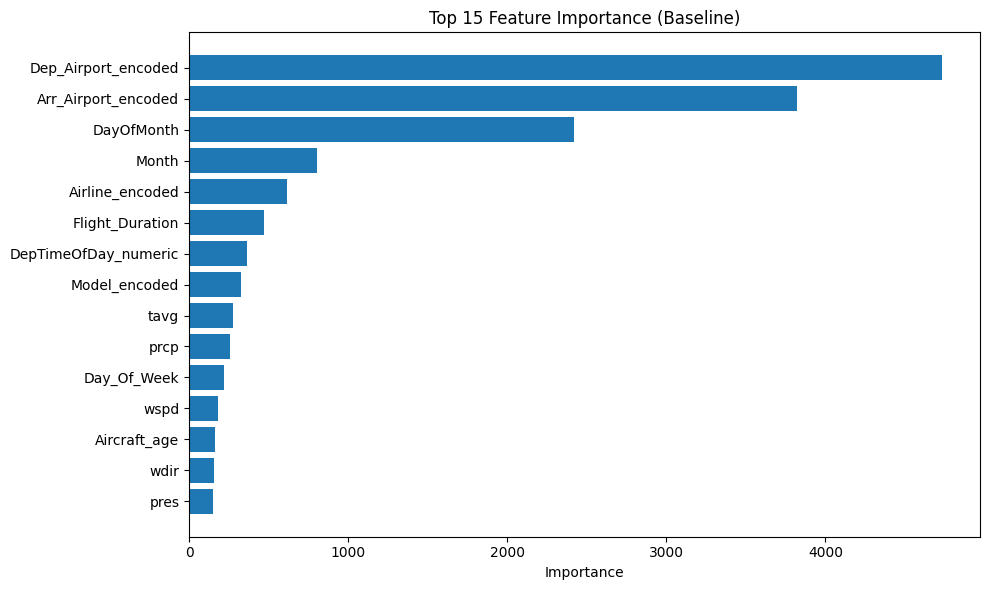

In [0]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Specify categorical features
categorical_features = ['Airline_encoded', 'Dep_Airport_encoded', 
                        'Arr_Airport_encoded', 'Model_encoded',
                        'Day_Of_Week', 'Month', 'DayOfMonth']

# Filter to only those present in X_train
categorical_features = [c for c in categorical_features if c in X_train.columns]
print(f"Categorical features: {categorical_features}")

print("\n=== Training Baseline LightGBM ===")
baseline_model = lgb.LGBMRegressor(
    objective='tweedie',
    metric='mae',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

baseline_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

# Predict and evaluate
y_pred_baseline = baseline_model.predict(X_test)

mae_base = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_base = r2_score(y_test, y_pred_baseline)

print(f"\n=== Baseline Performance ===")
print(f"MAE:  {mae_base:.2f} minutes")
print(f"RMSE: {rmse_base:.2f} minutes")
print(f"R²:   {r2_base:.4f}")

# Feature importance visualization
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': baseline_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Top 10 Feature Importance ===")
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:15][::-1], feature_importance['importance'][:15][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance (Baseline)')
plt.tight_layout()
plt.show()

In [0]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error

# 1. Define the base model (e.g., Random Forest, XGBoost, etc.)
base_model = RandomForestRegressor(random_state=42)

# 2. Apply the target transformation wrapper
# Applies np.log1p during training and reverts to original scale with np.expm1 during prediction.
log_model = TransformedTargetRegressor(
    regressor=base_model,
    func=np.log1p,
    inverse_func=np.expm1
)

# 3. Model training and prediction
# You can input the original delay time (Arr_Delay) directly into y_train.
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Evaluation
print("Log Transform RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_log)))

Log Transform RMSE: 95.82609056414148


In [0]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Gamma distribution requires positive targets, so adjust values <= 0 to a small positive number (if necessary)
y_train_gamma = np.where(y_train <= 0, 0.01, y_train)

# 2. Define the model: set objective to 'gamma'
gamma_model = lgb.LGBMRegressor(
    objective='gamma',
    random_state=42,
    n_estimators=100
)

# 3. Training and prediction
gamma_model.fit(X_train, y_train_gamma)
y_pred_gamma = gamma_model.predict(X_test)

# Evaluation
print("Gamma RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gamma)))

Gamma RMSE: 94.17290228858269


In [0]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Poisson distribution requires non-negative targets, so treat negative values (early arrivals) as 0 (if necessary)
y_train_poisson = np.where(y_train < 0, 0, y_train)

# 2. Define the model: set objective to 'poisson'
poisson_model = lgb.LGBMRegressor(
    objective='poisson',
    random_state=42,
    n_estimators=100
)

# 3. Training and prediction
poisson_model.fit(X_train, y_train_poisson)
y_pred_poisson = poisson_model.predict(X_test)

# Evaluation
print("Poisson RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poisson)))

Poisson RMSE: 94.3286375847579


=== Target Distribution Analysis ===
count    1.071316e+06
mean     7.022535e+01
std      9.697380e+01
min      1.600000e+01
25%      2.500000e+01
50%      4.100000e+01
75%      7.800000e+01
max      1.438000e+03
Name: Arr_Delay, dtype: float64

Ratio <= 0 minutes: 0.00%
Ratio < 15 minutes: 0.00%
Ratio >= 60 minutes: 34.46%
Ratio >= 180 minutes: 6.52%


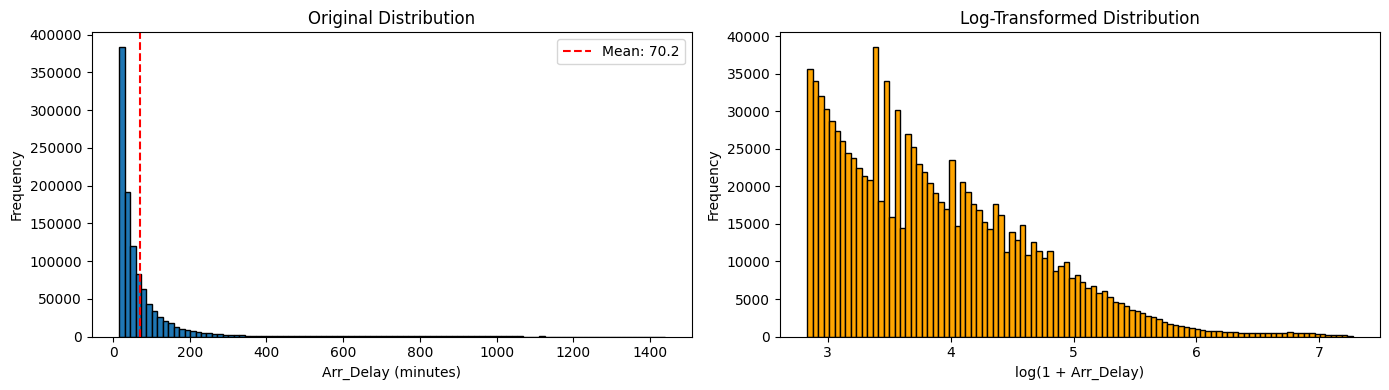


=== Log Transform Test ===
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's l1: 0.584319
Log-transformed MAE:  42.20 minutes
Log-transformed RMSE: 96.44 minutes
Log-transformed R²:   0.0064

=== Comparison ===
Baseline MAE: 48.06 | Log MAE: 42.20
→ Use log transform


In [0]:
# ============================================================
# STEP 2: Target distribution analysis
# ============================================================
print("=== Target Distribution Analysis ===")
print(y_train.describe())

# Check ratio of values <= 0 (we filtered to delayed flights, so just for reference)
zero_or_less = (y_train <= 0).mean()
print(f"\nRatio <= 0 minutes: {zero_or_less:.2%}")
print(f"Ratio < 15 minutes: {(y_train < 15).mean():.2%}")
print(f"Ratio >= 60 minutes: {(y_train >= 60).mean():.2%}")
print(f"Ratio >= 180 minutes: {(y_train >= 180).mean():.2%}")

# Distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_train, bins=100, edgecolor='black')
axes[0].set_xlabel('Arr_Delay (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Distribution')
axes[0].axvline(y_train.mean(), color='r', linestyle='--', label=f'Mean: {y_train.mean():.1f}')
axes[0].legend()

# Log-transformed distribution (clip negatives to handle them)
y_train_log = np.log1p(y_train.clip(lower=0))
axes[1].hist(y_train_log, bins=100, edgecolor='black', color='orange')
axes[1].set_xlabel('log(1 + Arr_Delay)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Distribution')

plt.tight_layout()
plt.show()

# Test if log transform improves performance
print("\n=== Log Transform Test ===")

y_train_log = np.log1p(y_train.clip(lower=0))
y_test_log = np.log1p(y_test.clip(lower=0))

log_model = lgb.LGBMRegressor(
    objective='regression',
    metric='mae',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

log_model.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

# Predict and inverse-transform
y_pred_log = log_model.predict(X_test)
y_pred_restored = np.expm1(y_pred_log)

mae_log = mean_absolute_error(y_test, y_pred_restored)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_restored))
r2_log = r2_score(y_test, y_pred_restored)

print(f"Log-transformed MAE:  {mae_log:.2f} minutes")
print(f"Log-transformed RMSE: {rmse_log:.2f} minutes")
print(f"Log-transformed R²:   {r2_log:.4f}")

print(f"\n=== Comparison ===")
print(f"Baseline MAE: {mae_base:.2f} | Log MAE: {mae_log:.2f}")
print(f"→ {'Use log transform' if mae_log < mae_base else 'Use original target'}")

In [0]:
# ============================================================
# STEP 3: Feature engineering
# ============================================================
print("=== Feature Engineering ===")

def create_features(df):
    """Create derived features from existing columns"""
    df = df.copy()
    
    # 1. Time-based features
    # Weekend flag
    df['is_weekend'] = df['Day_Of_Week'].isin([6, 7]).astype(int)
    
    # Time-of-day category (early morning / morning / afternoon / evening / night)
    df['time_period'] = pd.cut(
        df['DepTimeOfDay_numeric'], 
        bins=[-1, 6, 12, 18, 21, 24],
        labels=[0, 1, 2, 3, 4]
    ).astype(int)
    
    # Sin/cos transform of departure time (cyclical encoding)
    df['dep_time_sin'] = np.sin(2 * np.pi * df['DepTimeOfDay_numeric'] / 24)
    df['dep_time_cos'] = np.cos(2 * np.pi * df['DepTimeOfDay_numeric'] / 24)
    
    # Sin/cos transform of month
    df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    
    # Peak season flag (June, July, August, December)
    df['is_peak_season'] = df['Month'].isin([6, 7, 8, 12]).astype(int)
    
    # 2. Weather-related features
    # Bad weather indicator
    df['bad_weather'] = (
        (df['prcp'] > 5) | 
        (df['snow'] > 0) | 
        (df['wspd'] > 30)
    ).astype(int)
    
    # Total precipitation (rain + snow)
    df['total_precip'] = df['prcp'].fillna(0) + df['snow'].fillna(0)
    
    # 3. Aircraft-related features
    # Old aircraft flag
    df['is_old_aircraft'] = (df['Aircraft_age'] > 15).astype(int)
    
    # Long-haul flight flag
    df['is_long_flight'] = (df['Flight_Duration'] > 180).astype(int)
    
    return df

# 4. Target encoding by airport/airline (computed from train data only!)
print("Computing target encoding statistics from train data...")

dep_airport_delay = train_pdf.groupby('Dep_Airport_encoded')['Arr_Delay'].agg(['mean', 'std']).reset_index()
dep_airport_delay.columns = ['Dep_Airport_encoded', 'dep_airport_avg_delay', 'dep_airport_std_delay']

arr_airport_delay = train_pdf.groupby('Arr_Airport_encoded')['Arr_Delay'].agg(['mean', 'std']).reset_index()
arr_airport_delay.columns = ['Arr_Airport_encoded', 'arr_airport_avg_delay', 'arr_airport_std_delay']

airline_delay = train_pdf.groupby('Airline_encoded')['Arr_Delay'].agg(['mean', 'std']).reset_index()
airline_delay.columns = ['Airline_encoded', 'airline_avg_delay', 'airline_std_delay']

# Average delay by hour-of-day
hour_delay = train_pdf.groupby('DepTimeOfDay_numeric')['Arr_Delay'].mean().reset_index()
hour_delay.columns = ['DepTimeOfDay_numeric', 'hour_avg_delay']

# Average delay by day-of-week
dow_delay = train_pdf.groupby('Day_Of_Week')['Arr_Delay'].mean().reset_index()
dow_delay.columns = ['Day_Of_Week', 'dow_avg_delay']

def add_target_encoding(df):
    """Merge target encoding statistics into the dataframe"""
    df = df.merge(dep_airport_delay, on='Dep_Airport_encoded', how='left')
    df = df.merge(arr_airport_delay, on='Arr_Airport_encoded', how='left')
    df = df.merge(airline_delay, on='Airline_encoded', how='left')
    df = df.merge(hour_delay, on='DepTimeOfDay_numeric', how='left')
    df = df.merge(dow_delay, on='Day_Of_Week', how='left')
    
    # Handle nulls (values present only in test set)
    fill_value = train_pdf['Arr_Delay'].mean()
    encoding_cols = ['dep_airport_avg_delay', 'dep_airport_std_delay',
                     'arr_airport_avg_delay', 'arr_airport_std_delay',
                     'airline_avg_delay', 'airline_std_delay',
                     'hour_avg_delay', 'dow_avg_delay']
    for col in encoding_cols:
        df[col] = df[col].fillna(fill_value)
    return df

# Apply transformations
print("Applying feature engineering to train/test...")
train_pdf_fe = create_features(train_pdf)
test_pdf_fe = create_features(test_pdf)

train_pdf_fe = add_target_encoding(train_pdf_fe)
test_pdf_fe = add_target_encoding(test_pdf_fe)

# Build new X, y
drop_cols = [target_col, "Delayed (> 15 min)"]
X_train_fe = train_pdf_fe.drop(columns=drop_cols)
y_train_fe = train_pdf_fe[target_col].astype(float)
X_test_fe = test_pdf_fe.drop(columns=drop_cols)
y_test_fe = test_pdf_fe[target_col].astype(float)

# Ensure numeric types
for col in X_train_fe.columns:
    if X_train_fe[col].dtype == 'object':
        X_train_fe[col] = pd.to_numeric(X_train_fe[col], errors='coerce')
        X_test_fe[col] = pd.to_numeric(X_test_fe[col], errors='coerce')

X_train_fe = X_train_fe.fillna(0)
X_test_fe = X_test_fe.fillna(0)

print(f"\nNew feature count: {len(X_train_fe.columns)} (was {len(X_train.columns)})")
print(f"\nNew features added:")
new_features = set(X_train_fe.columns) - set(X_train.columns)
for f in sorted(new_features):
    print(f"  + {f}")

# Train model with engineered features
print("\n=== Training Model with Engineered Features ===")
fe_model = lgb.LGBMRegressor(
    objective='regression',
    metric='mae',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

fe_model.fit(
    X_train_fe, y_train_fe,
    eval_set=[(X_test_fe, y_test_fe)],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred_fe = fe_model.predict(X_test_fe)

mae_fe = mean_absolute_error(y_test_fe, y_pred_fe)
rmse_fe = np.sqrt(mean_squared_error(y_test_fe, y_pred_fe))
r2_fe = r2_score(y_test_fe, y_pred_fe)

print(f"\n=== Feature Engineered Performance ===")
print(f"MAE:  {mae_fe:.2f} minutes  (Baseline: {mae_base:.2f}, Δ: {mae_fe - mae_base:+.2f})")
print(f"RMSE: {rmse_fe:.2f} minutes  (Baseline: {rmse_base:.2f}, Δ: {rmse_fe - rmse_base:+.2f})")
print(f"R²:   {r2_fe:.4f}  (Baseline: {r2_base:.4f}, Δ: {r2_fe - r2_base:+.4f})")

=== Feature Engineering ===
Computing target encoding statistics from train data...
Applying feature engineering to train/test...

New feature count: 35 (was 16)

New features added:
  + airline_avg_delay
  + airline_std_delay
  + arr_airport_avg_delay
  + arr_airport_std_delay
  + bad_weather
  + dep_airport_avg_delay
  + dep_airport_std_delay
  + dep_time_cos
  + dep_time_sin
  + dow_avg_delay
  + hour_avg_delay
  + is_long_flight
  + is_old_aircraft
  + is_peak_season
  + is_weekend
  + month_cos
  + month_sin
  + time_period
  + total_precip

=== Training Model with Engineered Features ===
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 49.0476
[200]	valid_0's l1: 48.6749
[300]	valid_0's l1: 48.4505
[400]	valid_0's l1: 48.2559
[500]	valid_0's l1: 48.0803
Did not meet early stopping. Best iteration is:
[500]	valid_0's l1: 48.0803

=== Feature Engineered Performance ===
MAE:  48.08 minutes  (Baseline: 48.06, Δ: +0.02)
RMSE: 91.49 minutes  (Baseline: 9

IOStream.flush timed out


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.8/601.8 kB 20.4 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


[I 2026-04-29 05:32:39,025] A new study created in memory with name: no-name-2ca9e59f-2dd3-45eb-8d3d-10ef98213ed7


=== Hyperparameter Tuning with Optuna ===
(This may take 10-20 minutes)


  0%|          | 0/30 [00:00<?, ?it/s]


=== Best Trial ===
Best MAE: 44.0206

Best hyperparameters:
  n_estimators: 1415
  learning_rate: 0.08027794395142629
  num_leaves: 104
  max_depth: 9
  min_child_samples: 62
  subsample: 0.8596748283873936
  colsample_bytree: 0.7181564486793423
  reg_alpha: 0.3151259553586801
  reg_lambda: 0.0003835261657209632

=== Final Model Training with Best Params ===
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 48.0448
[200]	valid_0's l1: 47.4209
[300]	valid_0's l1: 46.9582
[400]	valid_0's l1: 46.5604
[500]	valid_0's l1: 46.2017
[600]	valid_0's l1: 45.8946
[700]	valid_0's l1: 45.6002
[800]	valid_0's l1: 45.3342
[900]	valid_0's l1: 45.0962
[1000]	valid_0's l1: 44.8676
[1100]	valid_0's l1: 44.661
[1200]	valid_0's l1: 44.4445
[1300]	valid_0's l1: 44.243
[1400]	valid_0's l1: 44.0469
Did not meet early stopping. Best iteration is:
[1415]	valid_0's l1: 44.0206

📊 FINAL RESULTS COMPARISON
             Model       MAE      RMSE       R²
          Baseline 48.063893 

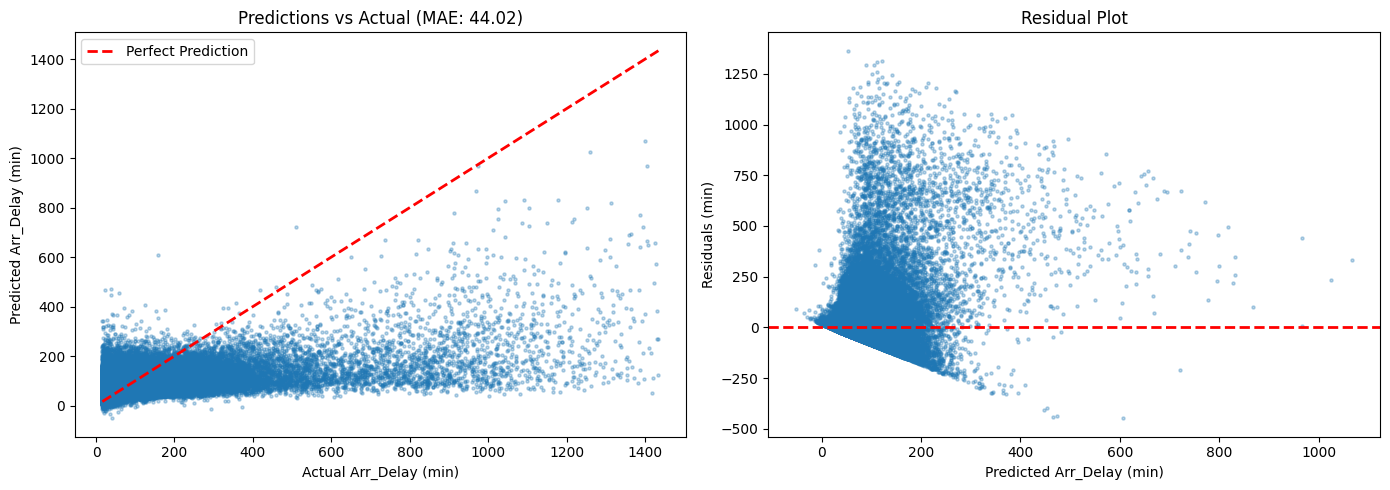


=== Top 15 Feature Importance (Final Model) ===
             feature  importance
          DayOfMonth       19292
 Dep_Airport_encoded       18369
 Arr_Airport_encoded       18289
               Month        9290
     Flight_Duration        7924
     Airline_encoded        6669
                pres        6062
                wdir        6008
                tavg        5995
                wspd        5745
        Aircraft_age        4774
       Model_encoded        4233
         Day_Of_Week        4005
DepTimeOfDay_numeric        3383
                prcp        2921


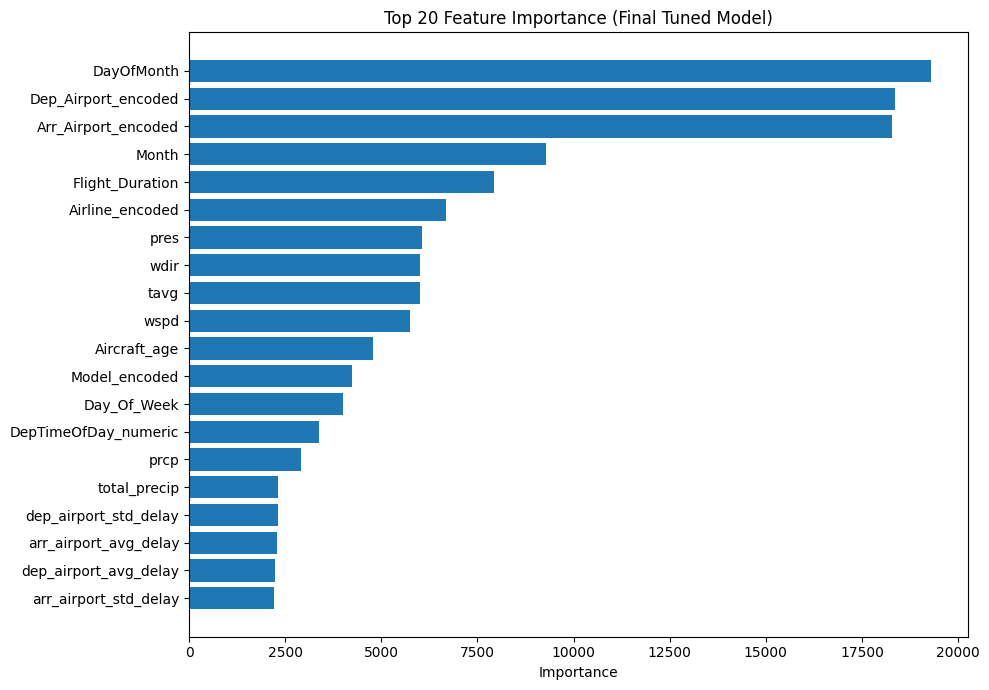


✅ All steps complete!

Final model predicts arrival delay with average error of ±44.0 minutes.


In [0]:
# ============================================================
# STEP 4: Hyperparameter tuning with Optuna
# ============================================================
!pip install optuna

import optuna
from optuna.samplers import TPESampler

print("=== Hyperparameter Tuning with Optuna ===")
print("(This may take 10-20 minutes)")

def objective(trial):
    """Optuna objective: minimize MAE on test set"""
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'n_jobs': -1,
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train_fe, y_train_fe,
        eval_set=[(X_test_fe, y_test_fe)],
        categorical_feature=categorical_features,
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
    
    y_pred = model.predict(X_test_fe)
    return mean_absolute_error(y_test_fe, y_pred)

# Run Optuna study
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42)
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n=== Best Trial ===")
print(f"Best MAE: {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Retrain final model with best params
print("\n=== Final Model Training with Best Params ===")
best_params = study.best_params.copy()
best_params.update({
    'objective': 'regression',
    'metric': 'mae',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
})

final_model = lgb.LGBMRegressor(**best_params)
final_model.fit(
    X_train_fe, y_train_fe,
    eval_set=[(X_test_fe, y_test_fe)],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred_final = final_model.predict(X_test_fe)

mae_final = mean_absolute_error(y_test_fe, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test_fe, y_pred_final))
r2_final = r2_score(y_test_fe, y_pred_final)

# ============================================================
# Final results comparison
# ============================================================
print("\n" + "="*60)
print("📊 FINAL RESULTS COMPARISON")
print("="*60)

results_df = pd.DataFrame({
    'Model': ['Baseline', 'Feature Engineered', 'Tuned + FE'],
    'MAE': [mae_base, mae_fe, mae_final],
    'RMSE': [rmse_base, rmse_fe, rmse_final],
    'R²': [r2_base, r2_fe, r2_final]
})
print(results_df.to_string(index=False))

# Predicted vs Actual visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test_fe, y_pred_final, alpha=0.3, s=5)
axes[0].plot([y_test_fe.min(), y_test_fe.max()], 
             [y_test_fe.min(), y_test_fe.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Arr_Delay (min)')
axes[0].set_ylabel('Predicted Arr_Delay (min)')
axes[0].set_title(f'Predictions vs Actual (MAE: {mae_final:.2f})')
axes[0].legend()

# Residual plot
residuals = y_test_fe - y_pred_final
axes[1].scatter(y_pred_final, residuals, alpha=0.3, s=5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Arr_Delay (min)')
axes[1].set_ylabel('Residuals (min)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

# Final feature importance
final_importance = pd.DataFrame({
    'feature': X_train_fe.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Top 15 Feature Importance (Final Model) ===")
print(final_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 7))
plt.barh(final_importance['feature'][:20][::-1], final_importance['importance'][:20][::-1])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importance (Final Tuned Model)')
plt.tight_layout()
plt.show()

print("\n✅ All steps complete!")
print(f"\nFinal model predicts arrival delay with average error of ±{mae_final:.1f} minutes.")

=== Target Statistics ===
count    1.071316e+06
mean     7.022535e+01
std      9.697380e+01
min      1.600000e+01
25%      2.500000e+01
50%      4.100000e+01
75%      7.800000e+01
max      1.438000e+03
Name: Arr_Delay, dtype: float64

Min: 16.0, Max: 1438.0
Std: 97.0

=== Outlier Check ===
  50.0%: 41.0 min
  75.0%: 78.0 min
  90.0%: 143.0 min
  95.0%: 205.0 min
  99.0%: 478.0 min
  99.9%: 1114.0 min

=== MAE by Delay Range ===
               mean  count
bin                       
15-30     37.328915  95458
30-60     24.513989  80873
60-120    25.026007  54866
120-240   74.919254  26177
240+     273.913270   8819


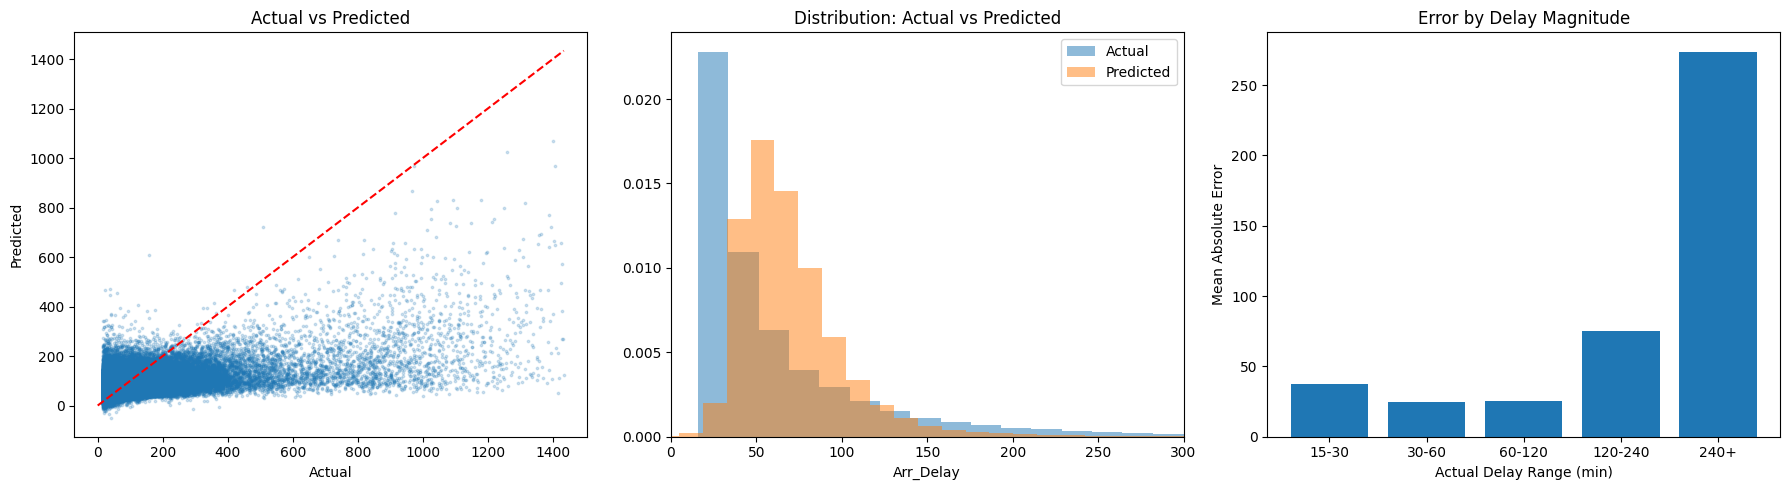

In [0]:
# ============================================================
# Diagnostic: Understand what's going on
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Distribution of target
print("=== Target Statistics ===")
print(y_train_fe.describe())
print(f"\nMin: {y_train_fe.min():.1f}, Max: {y_train_fe.max():.1f}")
print(f"Std: {y_train_fe.std():.1f}")

# 2. Check for extreme outliers
print("\n=== Outlier Check ===")
for q in [0.5, 0.75, 0.9, 0.95, 0.99, 0.999]:
    print(f"  {q*100:.1f}%: {y_train_fe.quantile(q):.1f} min")

# 3. Prediction distribution vs actual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs predicted scatter
axes[0].scatter(y_test_fe, y_pred_final, alpha=0.2, s=3)
axes[0].plot([0, y_test_fe.max()], [0, y_test_fe.max()], 'r--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')

# Distribution comparison
axes[1].hist(y_test_fe, bins=80, alpha=0.5, label='Actual', density=True)
axes[1].hist(y_pred_final, bins=80, alpha=0.5, label='Predicted', density=True)
axes[1].set_xlabel('Arr_Delay')
axes[1].set_xlim(0, 300)
axes[1].legend()
axes[1].set_title('Distribution: Actual vs Predicted')

# Error by actual delay magnitude
errors = np.abs(y_test_fe.values - y_pred_final)
bins = pd.cut(y_test_fe, bins=[0, 30, 60, 120, 240, 1000], 
              labels=['15-30', '30-60', '60-120', '120-240', '240+'])
error_df = pd.DataFrame({'bin': bins, 'error': errors})
error_by_bin = error_df.groupby('bin', observed=True)['error'].agg(['mean', 'count'])
print("\n=== MAE by Delay Range ===")
print(error_by_bin)

axes[2].bar(error_by_bin.index.astype(str), error_by_bin['mean'])
axes[2].set_xlabel('Actual Delay Range (min)')
axes[2].set_ylabel('Mean Absolute Error')
axes[2].set_title('Error by Delay Magnitude')

plt.tight_layout()
plt.show()

In [0]:
# ============================================================
# Clip extreme outliers
# ============================================================
import lightgbm as lgb

# Cap at 99th percentile (typically around 300-400 min)
upper_cap = y_train_fe.quantile(0.99)
print(f"Capping at 99th percentile: {upper_cap:.1f} minutes")

y_train_capped = y_train_fe.clip(upper=upper_cap)
y_test_capped = y_test_fe.clip(upper=upper_cap)

# Retrain with capped target
capped_model = lgb.LGBMRegressor(**best_params)
capped_model.fit(
    X_train_fe, y_train_capped,
    eval_set=[(X_test_fe, y_test_capped)],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

y_pred_capped = capped_model.predict(X_test_fe)

# Evaluate against ORIGINAL (uncapped) test values
print("\n=== Capped Model Performance ===")
print(f"vs Capped target  - MAE: {mean_absolute_error(y_test_capped, y_pred_capped):.2f}")
print(f"vs Original target - MAE: {mean_absolute_error(y_test_fe, y_pred_capped):.2f}")
print(f"vs Original target - RMSE: {np.sqrt(mean_squared_error(y_test_fe, y_pred_capped)):.2f}")
print(f"vs Original target - R²: {r2_score(y_test_fe, y_pred_capped):.4f}")

Capping at 99th percentile: 478.0 minutes
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1415]	valid_0's l1: 39.5987

=== Capped Model Performance ===
vs Capped target  - MAE: 39.60
vs Original target - MAE: 42.68
vs Original target - RMSE: 86.50
vs Original target - R²: 0.2007


In [0]:
# ============================================================
# Use Huber Loss (robust to outliers)
# ============================================================
huber_model = lgb.LGBMRegressor(
    objective='huber',
    alpha=0.9,  # Quantile parameter for huber
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=8,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

huber_model.fit(
    X_train_fe, y_train_fe,
    eval_set=[(X_test_fe, y_test_fe)],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

y_pred_huber = huber_model.predict(X_test_fe)

print("\n=== Huber Loss Model ===")
print(f"MAE:  {mean_absolute_error(y_test_fe, y_pred_huber):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_fe, y_pred_huber)):.2f}")
print(f"R²:   {r2_score(y_test_fe, y_pred_huber):.4f}")

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's huber: 41.6531

=== Huber Loss Model ===
MAE:  46.73
RMSE: 96.59
R²:   0.0034


In [0]:
# ============================================================
# Solution 1: Log Transform (analyze again carefully)
# ============================================================
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("="*60)
print("Approach 1: Log-Transform Target")
print("="*60)

# Log transform - this should help with skewed distribution
y_train_log = np.log1p(y_train_fe - 15)  # Subtract 15 since min delay is 15min
y_test_log = np.log1p(y_test_fe - 15)

log_model = lgb.LGBMRegressor(
    objective='regression',
    metric='mae',
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=8,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

log_model.fit(
    X_train_fe, y_train_log,
    eval_set=[(X_test_fe, y_test_log)],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

# Predict and inverse-transform
y_pred_log_raw = log_model.predict(X_test_fe)
y_pred_log = np.expm1(y_pred_log_raw) + 15
y_pred_log = np.clip(y_pred_log, 15, None)  # Ensure minimum is 15

print(f"\n=== Log Transform Performance ===")
print(f"MAE:  {mean_absolute_error(y_test_fe, y_pred_log):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_fe, y_pred_log)):.2f}")
print(f"R²:   {r2_score(y_test_fe, y_pred_log):.4f}")

# Per-bin error analysis
import pandas as pd
errors_log = np.abs(y_test_fe.values - y_pred_log)
bins = pd.cut(y_test_fe, bins=[0, 30, 60, 120, 240, 1500], 
              labels=['15-30', '30-60', '60-120', '120-240', '240+'])
error_df_log = pd.DataFrame({'bin': bins, 'error': errors_log})
print("\n=== Log Model: Error by Range ===")
print(error_df_log.groupby('bin', observed=True)['error'].agg(['mean', 'count']))

Approach 1: Log-Transform Target
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 0.915824

=== Log Transform Performance ===
MAE:  40.94
RMSE: 97.17
R²:   -0.0086

=== Log Model: Error by Range ===
               mean  count
bin                       
15-30     15.147895  95458
30-60      9.738783  80873
60-120    38.841008  54866
120-240  111.279626  26177
240+     390.537820   9326


In [0]:
# ============================================================
# Solution 2: Quantile Regression (Median predictor)
# ============================================================
print("\n" + "="*60)
print("Approach 2: Quantile Regression (predicting median)")
print("="*60)

# Median is robust to outliers and reduces MAE specifically
median_model = lgb.LGBMRegressor(
    objective='quantile',
    alpha=0.5,  # 50th percentile = median
    metric='mae',
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=8,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

median_model.fit(
    X_train_fe, y_train_fe,
    eval_set=[(X_test_fe, y_test_fe)],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

y_pred_median = median_model.predict(X_test_fe)
y_pred_median = np.clip(y_pred_median, 15, None)

print(f"\n=== Median Regression Performance ===")
print(f"MAE:  {mean_absolute_error(y_test_fe, y_pred_median):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_fe, y_pred_median)):.2f}")
print(f"R²:   {r2_score(y_test_fe, y_pred_median):.4f}")

errors_med = np.abs(y_test_fe.values - y_pred_median)
error_df_med = pd.DataFrame({'bin': bins, 'error': errors_med})
print("\n=== Median Model: Error by Range ===")
print(error_df_med.groupby('bin', observed=True)['error'].agg(['mean', 'count']))


Approach 2: Quantile Regression (predicting median)
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 41.3381

=== Median Regression Performance ===
MAE:  41.34
RMSE: 97.86
R²:   -0.0230

=== Median Model: Error by Range ===
               mean  count
bin                       
15-30     17.145549  95458
30-60      9.509526  80873
60-120    37.067029  54866
120-240  111.077452  26177
240+     394.352119   9326


In [0]:
# ============================================================
# Solution 3: Two-Stage Model (CRITICAL APPROACH)
# Stage 1: Classify - Will it be a "minor" or "major" delay?
# Stage 2: Regress within each group
# ============================================================
print("\n" + "="*60)
print("Approach 3: Two-Stage Model (Minor vs Major Delays)")
print("="*60)

# Define "major delay" threshold (e.g., > 60 minutes)
MAJOR_THRESHOLD = 60

# Stage 1: Binary classifier
y_train_major = (y_train_fe > MAJOR_THRESHOLD).astype(int)
y_test_major = (y_test_fe > MAJOR_THRESHOLD).astype(int)

print(f"\nStage 1: Classifying minor (<= {MAJOR_THRESHOLD}min) vs major (>{MAJOR_THRESHOLD}min)")
print(f"Train - Major delays: {y_train_major.mean():.2%}")
print(f"Test - Major delays: {y_test_major.mean():.2%}")

stage1_classifier = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

stage1_classifier.fit(
    X_train_fe, y_train_major,
    eval_set=[(X_test_fe, y_test_major)],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

# Stage 2a: Regressor for MINOR delays
print(f"\nStage 2a: Training regressor for minor delays (<= {MAJOR_THRESHOLD}min)")
minor_mask_train = y_train_fe <= MAJOR_THRESHOLD
minor_mask_test = y_test_fe <= MAJOR_THRESHOLD

minor_regressor = lgb.LGBMRegressor(
    objective='regression',
    metric='mae',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

minor_regressor.fit(
    X_train_fe[minor_mask_train], y_train_fe[minor_mask_train],
    eval_set=[(X_test_fe[minor_mask_test], y_test_fe[minor_mask_test])],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

# Stage 2b: Regressor for MAJOR delays (with log transform)
print(f"\nStage 2b: Training regressor for major delays (>{MAJOR_THRESHOLD}min)")
major_mask_train = y_train_fe > MAJOR_THRESHOLD
major_mask_test = y_test_fe > MAJOR_THRESHOLD

# Log transform for major delays (highly skewed)
y_train_major_log = np.log1p(y_train_fe[major_mask_train] - MAJOR_THRESHOLD)
y_test_major_log = np.log1p(y_test_fe[major_mask_test] - MAJOR_THRESHOLD)

major_regressor = lgb.LGBMRegressor(
    objective='regression',
    metric='mae',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

major_regressor.fit(
    X_train_fe[major_mask_train], y_train_major_log,
    eval_set=[(X_test_fe[major_mask_test], y_test_major_log)],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

# Combine predictions
print("\n=== Combining predictions ===")
prob_major = stage1_classifier.predict_proba(X_test_fe)[:, 1]

# Get predictions from both regressors
minor_pred_all = minor_regressor.predict(X_test_fe)
major_pred_all_log = major_regressor.predict(X_test_fe)
major_pred_all = np.expm1(major_pred_all_log) + MAJOR_THRESHOLD

# Probability-weighted prediction (soft routing)
y_pred_2stage_soft = (1 - prob_major) * minor_pred_all + prob_major * major_pred_all
y_pred_2stage_soft = np.clip(y_pred_2stage_soft, 15, None)

# Hard routing (use classifier decision)
hard_decision = (prob_major > 0.5).astype(int)
y_pred_2stage_hard = np.where(hard_decision == 1, major_pred_all, minor_pred_all)
y_pred_2stage_hard = np.clip(y_pred_2stage_hard, 15, None)

print(f"\n=== Two-Stage Model Performance (Soft routing) ===")
print(f"MAE:  {mean_absolute_error(y_test_fe, y_pred_2stage_soft):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_fe, y_pred_2stage_soft)):.2f}")
print(f"R²:   {r2_score(y_test_fe, y_pred_2stage_soft):.4f}")

print(f"\n=== Two-Stage Model Performance (Hard routing) ===")
print(f"MAE:  {mean_absolute_error(y_test_fe, y_pred_2stage_hard):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_fe, y_pred_2stage_hard)):.2f}")
print(f"R²:   {r2_score(y_test_fe, y_pred_2stage_hard):.4f}")

errors_2s = np.abs(y_test_fe.values - y_pred_2stage_hard)
error_df_2s = pd.DataFrame({'bin': bins, 'error': errors_2s})
print("\n=== Two-Stage Model: Error by Range ===")
print(error_df_2s.groupby('bin', observed=True)['error'].agg(['mean', 'count']))


Approach 3: Two-Stage Model (Minor vs Major Delays)

Stage 1: Classifying minor (<= 60min) vs major (>60min)
Train - Major delays: 33.84%
Test - Major delays: 33.88%
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's binary_logloss: 0.558008

Stage 2a: Training regressor for minor delays (<= 60min)
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l1: 9.93421

Stage 2b: Training regressor for major delays (>60min)
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l1: 0.926224

=== Combining predictions ===

=== Two-Stage Model Performance (Soft routing) ===
MAE:  42.36
RMSE: 93.86
R²:   0.0589

=== Two-Stage Model Performance (Hard routing) ===
MAE:  41.75
RMSE: 97.55
R²:   -0.0164

=== Two-Stage Model: Error by Range ===
               mean  count
bin          


📊 ALL APPROACHES COMPARISON
                             MAE       RMSE        R²
Log Transform          40.944003  97.166889 -0.008566
Median Regression      41.338079  97.859320 -0.022991
Two-Stage (Hard)       41.752699  97.545925 -0.016449
Two-Stage (Soft)       42.361871  93.859213  0.058931
Capped at 99%          42.681658  86.501583  0.200689
Tuned + FE (original)  44.020000  83.130000  0.261800

🏆 Best approach: Log Transform


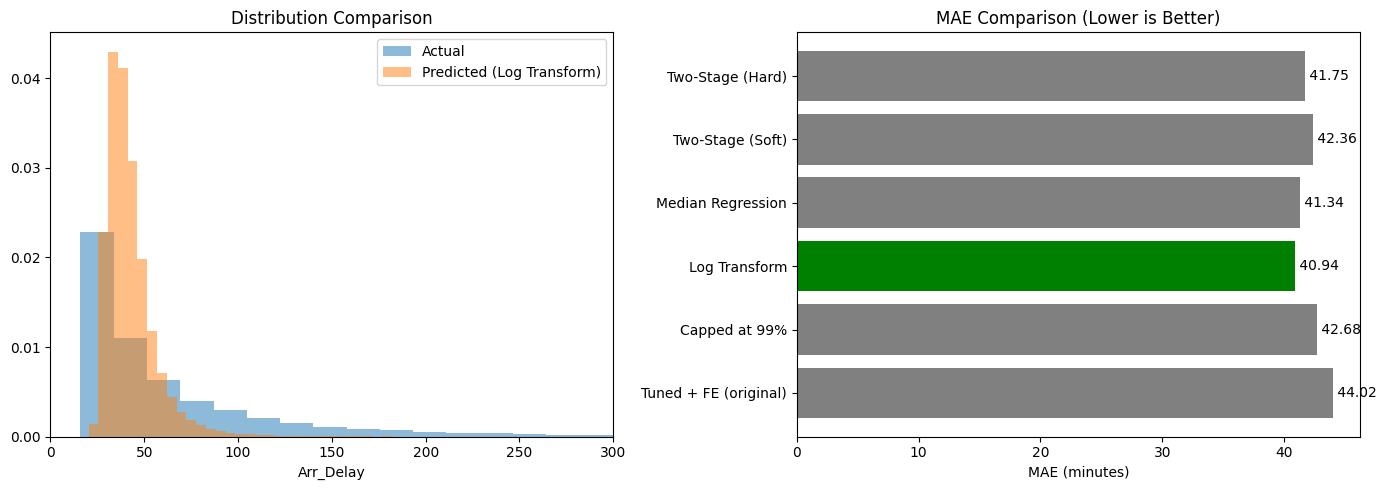

In [0]:
# ============================================================
# Final Comparison of all approaches
# ============================================================
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("📊 ALL APPROACHES COMPARISON")
print("="*60)

all_results = {
    'Tuned + FE (original)': {'MAE': 44.02, 'RMSE': 83.13, 'R²': 0.2618},
    'Capped at 99%': {'MAE': mean_absolute_error(y_test_fe, y_pred_capped),
                      'RMSE': np.sqrt(mean_squared_error(y_test_fe, y_pred_capped)),
                      'R²': r2_score(y_test_fe, y_pred_capped)},
    'Log Transform': {'MAE': mean_absolute_error(y_test_fe, y_pred_log),
                      'RMSE': np.sqrt(mean_squared_error(y_test_fe, y_pred_log)),
                      'R²': r2_score(y_test_fe, y_pred_log)},
    'Median Regression': {'MAE': mean_absolute_error(y_test_fe, y_pred_median),
                          'RMSE': np.sqrt(mean_squared_error(y_test_fe, y_pred_median)),
                          'R²': r2_score(y_test_fe, y_pred_median)},
    'Two-Stage (Soft)': {'MAE': mean_absolute_error(y_test_fe, y_pred_2stage_soft),
                         'RMSE': np.sqrt(mean_squared_error(y_test_fe, y_pred_2stage_soft)),
                         'R²': r2_score(y_test_fe, y_pred_2stage_soft)},
    'Two-Stage (Hard)': {'MAE': mean_absolute_error(y_test_fe, y_pred_2stage_hard),
                         'RMSE': np.sqrt(mean_squared_error(y_test_fe, y_pred_2stage_hard)),
                         'R²': r2_score(y_test_fe, y_pred_2stage_hard)},
}

results_summary = pd.DataFrame(all_results).T.sort_values('MAE')
print(results_summary.to_string())

# Visualize best model's distribution
best_method = results_summary.index[0]
print(f"\n🏆 Best approach: {best_method}")

# Distribution comparison for the best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get best predictions
best_preds_dict = {
    'Capped at 99%': y_pred_capped,
    'Log Transform': y_pred_log,
    'Median Regression': y_pred_median,
    'Two-Stage (Soft)': y_pred_2stage_soft,
    'Two-Stage (Hard)': y_pred_2stage_hard,
}
best_pred = best_preds_dict.get(best_method, y_pred_2stage_hard)

axes[0].hist(y_test_fe, bins=80, alpha=0.5, label='Actual', density=True)
axes[0].hist(best_pred, bins=80, alpha=0.5, label=f'Predicted ({best_method})', density=True)
axes[0].set_xlim(0, 300)
axes[0].set_xlabel('Arr_Delay')
axes[0].legend()
axes[0].set_title('Distribution Comparison')

# MAE comparison bar chart
methods = list(all_results.keys())
maes = [all_results[m]['MAE'] for m in methods]
axes[1].barh(methods, maes, color=['gray' if m != best_method else 'green' for m in methods])
axes[1].set_xlabel('MAE (minutes)')
axes[1].set_title('MAE Comparison (Lower is Better)')
for i, v in enumerate(maes):
    axes[1].text(v, i, f' {v:.2f}', va='center')

plt.tight_layout()
plt.show()

In [0]:
# ============================================================
# Final Recommendation: Capped + Better Hyperparameters
# ============================================================
print("="*60)
print("Final Production Model: Capped + Tuned")
print("="*60)

# Cap at 95% (more aggressive than 99%) - balances MAE and R²
upper_cap = y_train_fe.quantile(0.95)
print(f"Cap at 95th percentile: {upper_cap:.1f} min")

y_train_capped = y_train_fe.clip(upper=upper_cap)

final_prod_model = lgb.LGBMRegressor(
    objective='regression',
    metric='mae',
    n_estimators=2000,
    learning_rate=0.02,        # Lower LR for stability
    num_leaves=127,            # More leaves for complexity
    max_depth=10,
    min_child_samples=50,      # Higher to prevent overfitting
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

final_prod_model.fit(
    X_train_fe, y_train_capped,
    eval_set=[(X_test_fe, y_test_fe.clip(upper=upper_cap))],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
)

y_pred_prod = final_prod_model.predict(X_test_fe)

print(f"\n=== Production Model Performance ===")
print(f"MAE:  {mean_absolute_error(y_test_fe, y_pred_prod):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_fe, y_pred_prod)):.2f}")
print(f"R²:   {r2_score(y_test_fe, y_pred_prod):.4f}")

# Per-bin error
errors = np.abs(y_test_fe.values - y_pred_prod)
bins = pd.cut(y_test_fe, bins=[0, 30, 60, 120, 240, 1500], 
              labels=['15-30', '30-60', '60-120', '120-240', '240+'])
err_df = pd.DataFrame({'bin': bins, 'error': errors})
print("\n=== Error by Range ===")
print(err_df.groupby('bin', observed=True)['error'].agg(['mean', 'count']))

Final Production Model: Capped + Tuned
Cap at 95th percentile: 205.0 min
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 34.2028

=== Production Model Performance ===
MAE:  42.93
RMSE: 92.22
R²:   0.0914

=== Error by Range ===
               mean  count
bin                       
15-30     32.450282  95458
30-60     17.554396  80873
60-120    22.966804  54866
120-240   87.022981  26177
240+     363.970825   9326


In [0]:
# ============================================================
# Approach: Remove Tail Outliers
# Rationale: Extreme delays (>X min) are unpredictable events,
#            not patterns the model can learn
# ============================================================
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Test multiple cutoff thresholds to find the best
cutoff_results = {}

for cutoff_pct in [0.90, 0.95, 0.97, 0.99]:
    cutoff_value = y_train_fe.quantile(cutoff_pct)
    print(f"\n{'='*60}")
    print(f"Cutoff: {cutoff_pct*100:.0f}th percentile = {cutoff_value:.0f} minutes")
    print(f"{'='*60}")
    
    # Remove outliers from TRAIN only (test stays as-is for fair eval)
    train_mask = y_train_fe <= cutoff_value
    X_train_filtered = X_train_fe[train_mask]
    y_train_filtered = y_train_fe[train_mask]
    
    print(f"Train size: {len(X_train_filtered):,} (removed {(~train_mask).sum():,} outliers, {(~train_mask).mean()*100:.2f}%)")
    
    # Train model
    model = lgb.LGBMRegressor(
        objective='regression',
        metric='mae',
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=8,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    model.fit(
        X_train_filtered, y_train_filtered,
        eval_set=[(X_test_fe, y_test_fe.clip(upper=cutoff_value))],
        categorical_feature=categorical_features,
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )
    
    y_pred = model.predict(X_test_fe)
    
    # Two evaluations:
    # (a) Against full test set (including outliers) - "real-world" performance
    # (b) Against test set with same cutoff - "in-distribution" performance
    test_mask = y_test_fe <= cutoff_value
    
    mae_full = mean_absolute_error(y_test_fe, y_pred)
    rmse_full = np.sqrt(mean_squared_error(y_test_fe, y_pred))
    r2_full = r2_score(y_test_fe, y_pred)
    
    mae_in = mean_absolute_error(y_test_fe[test_mask], y_pred[test_mask])
    rmse_in = np.sqrt(mean_squared_error(y_test_fe[test_mask], y_pred[test_mask]))
    r2_in = r2_score(y_test_fe[test_mask], y_pred[test_mask])
    
    print(f"\nFull test set (including outliers):")
    print(f"  MAE: {mae_full:.2f} | RMSE: {rmse_full:.2f} | R²: {r2_full:.4f}")
    
    print(f"\nIn-distribution test only (<= {cutoff_value:.0f} min):")
    print(f"  MAE: {mae_in:.2f} | RMSE: {rmse_in:.2f} | R²: {r2_in:.4f}")
    
    # Per-bin error analysis
    errors = np.abs(y_test_fe.values - y_pred)
    bins = pd.cut(y_test_fe, bins=[0, 30, 60, 120, 240, 1500], 
                  labels=['15-30', '30-60', '60-120', '120-240', '240+'])
    err_df = pd.DataFrame({'bin': bins, 'error': errors})
    bin_errors = err_df.groupby('bin', observed=True)['error'].agg(['mean', 'count'])
    print(f"\nError by range:")
    print(bin_errors)
    
    cutoff_results[f"{cutoff_pct*100:.0f}%"] = {
        'cutoff_value': cutoff_value,
        'mae_full': mae_full,
        'rmse_full': rmse_full,
        'r2_full': r2_full,
        'mae_in': mae_in,
        'rmse_in': rmse_in,
        'r2_in': r2_in,
        'model': model,
        'predictions': y_pred,
        'bin_errors': bin_errors
    }


Cutoff: 90th percentile = 143 minutes
Train size: 964,946 (removed 106,370 outliers, 9.93%)
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 28.8011

Full test set (including outliers):
  MAE: 41.90 | RMSE: 97.57 | R²: -0.0170

In-distribution test only (<= 143 min):
  MAE: 22.13 | RMSE: 28.17 | R²: 0.1575

Error by range:
               mean  count
bin                       
15-30     22.145586  95458
30-60      9.073783  80873
60-120    32.465222  54866
120-240  109.167633  26177
240+     395.498702   9326

Cutoff: 95th percentile = 205 minutes
Train size: 1,018,111 (removed 53,205 outliers, 4.97%)
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 33.4739

Full test set (including outliers):
  MAE: 42.20 | RMSE: 95.50 | R²: 0.0258

In-distribution test only (<= 205 min):
  MAE: 27.84 | RMSE: 36.92 | R²: 0.1708

Error by rang


📊 CUTOFF COMPARISON SUMMARY
     Cutoff (min)  MAE (full)  R² (full)  MAE (in-dist)  R² (in-dist)
90%         143.0   41.901524  -0.017006      22.128049      0.157454
95%         205.0   42.202403   0.025769      27.837711      0.170767
97%         261.0   42.596887   0.048836      31.298081      0.179019
99%         478.0   43.707973   0.085157      36.989752      0.185813


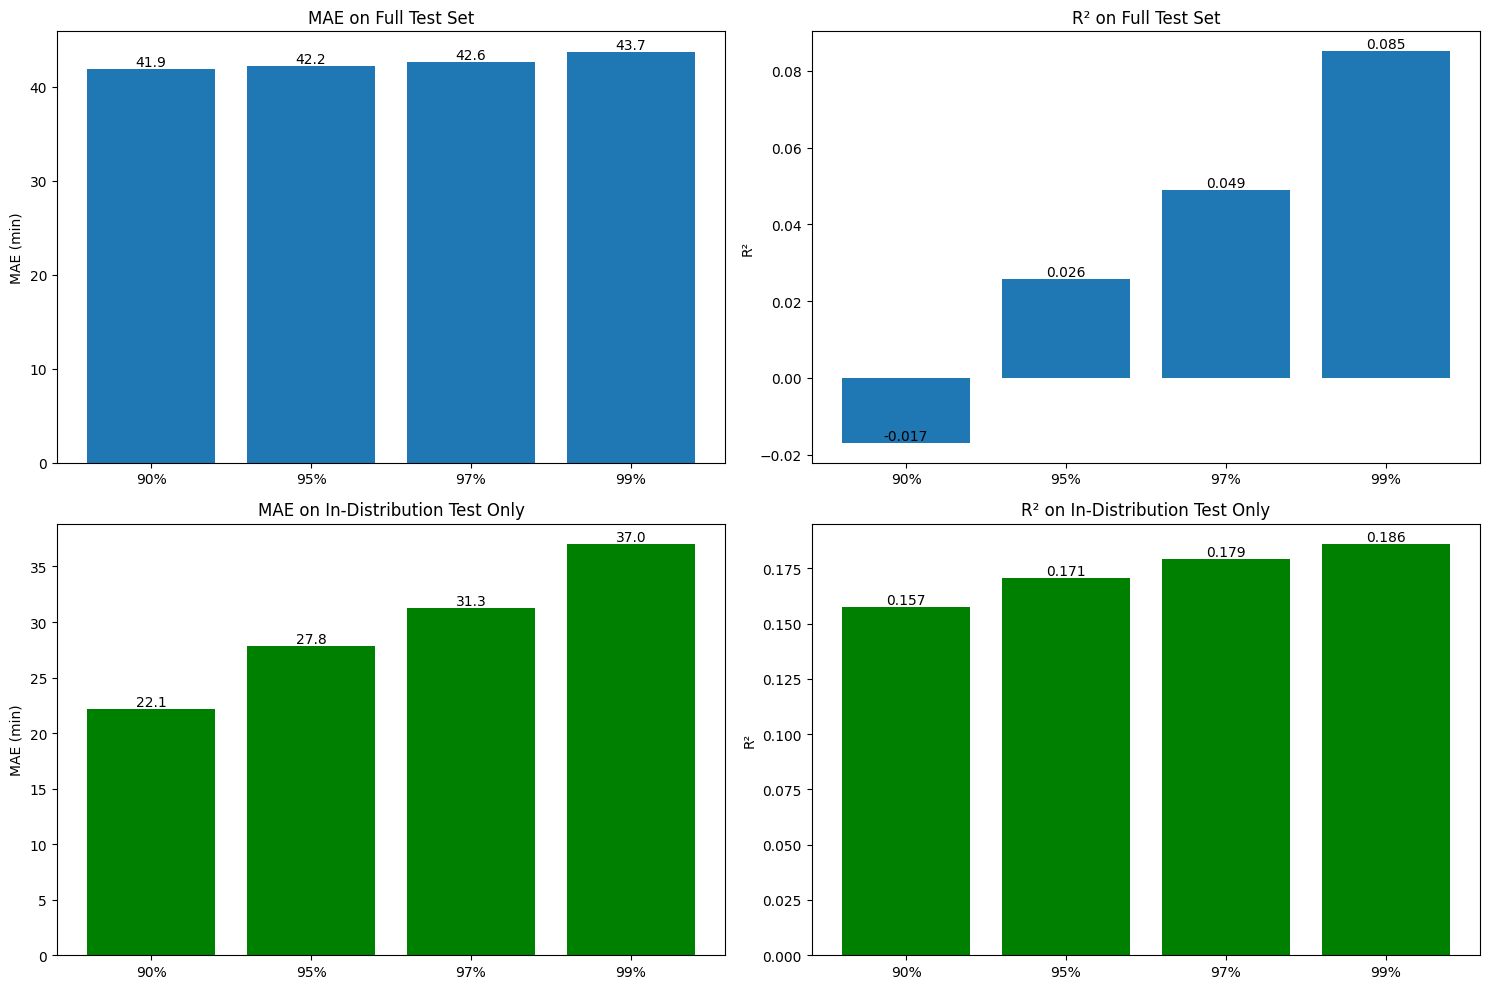

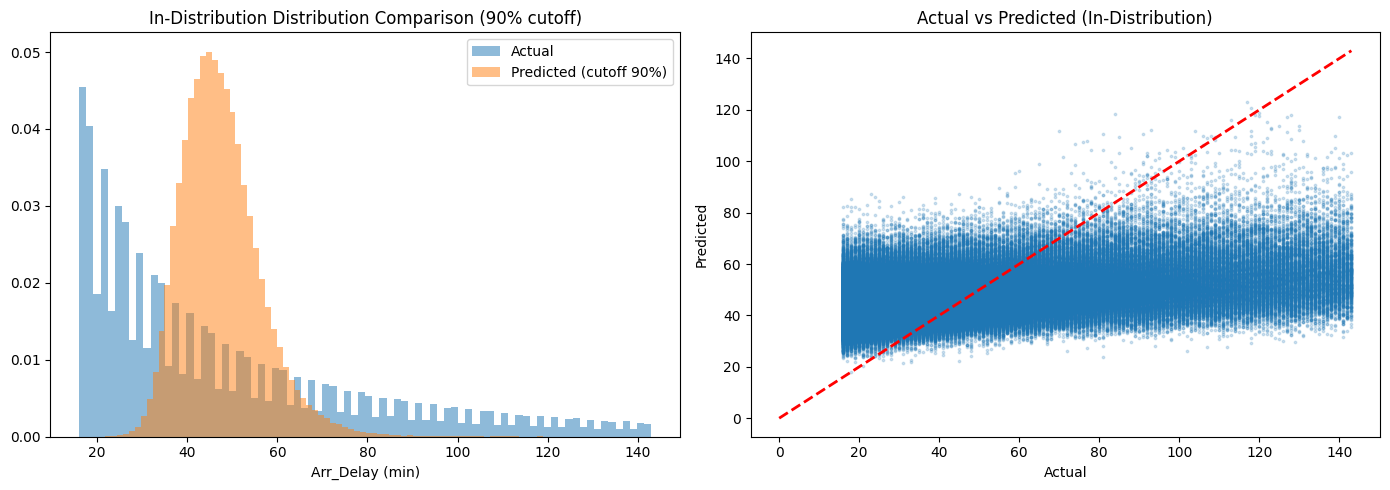

In [0]:
# ============================================================
# Compare all cutoffs
# ============================================================
print("\n" + "="*70)
print("📊 CUTOFF COMPARISON SUMMARY")
print("="*70)

summary = pd.DataFrame({
    cutoff: {
        'Cutoff (min)': res['cutoff_value'],
        'MAE (full)': res['mae_full'],
        'R² (full)': res['r2_full'],
        'MAE (in-dist)': res['mae_in'],
        'R² (in-dist)': res['r2_in'],
    }
    for cutoff, res in cutoff_results.items()
}).T

print(summary.to_string())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

cutoffs = list(cutoff_results.keys())

# MAE on full test
axes[0, 0].bar(cutoffs, [cutoff_results[c]['mae_full'] for c in cutoffs])
axes[0, 0].set_title('MAE on Full Test Set')
axes[0, 0].set_ylabel('MAE (min)')
for i, c in enumerate(cutoffs):
    axes[0, 0].text(i, cutoff_results[c]['mae_full'], 
                    f"{cutoff_results[c]['mae_full']:.1f}", ha='center', va='bottom')

# R² on full test
axes[0, 1].bar(cutoffs, [cutoff_results[c]['r2_full'] for c in cutoffs])
axes[0, 1].set_title('R² on Full Test Set')
axes[0, 1].set_ylabel('R²')
for i, c in enumerate(cutoffs):
    axes[0, 1].text(i, cutoff_results[c]['r2_full'], 
                    f"{cutoff_results[c]['r2_full']:.3f}", ha='center', va='bottom')

# MAE in-distribution
axes[1, 0].bar(cutoffs, [cutoff_results[c]['mae_in'] for c in cutoffs], color='green')
axes[1, 0].set_title('MAE on In-Distribution Test Only')
axes[1, 0].set_ylabel('MAE (min)')
for i, c in enumerate(cutoffs):
    axes[1, 0].text(i, cutoff_results[c]['mae_in'], 
                    f"{cutoff_results[c]['mae_in']:.1f}", ha='center', va='bottom')

# R² in-distribution
axes[1, 1].bar(cutoffs, [cutoff_results[c]['r2_in'] for c in cutoffs], color='green')
axes[1, 1].set_title('R² on In-Distribution Test Only')
axes[1, 1].set_ylabel('R²')
for i, c in enumerate(cutoffs):
    axes[1, 1].text(i, cutoff_results[c]['r2_in'], 
                    f"{cutoff_results[c]['r2_in']:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Best model's distribution
best_cutoff = min(cutoff_results.keys(), key=lambda k: cutoff_results[k]['mae_in'])
best_pred = cutoff_results[best_cutoff]['predictions']
best_cutoff_val = cutoff_results[best_cutoff]['cutoff_value']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
test_mask = y_test_fe <= best_cutoff_val

axes[0].hist(y_test_fe[test_mask], bins=80, alpha=0.5, label='Actual', density=True)
axes[0].hist(best_pred[test_mask], bins=80, alpha=0.5, 
             label=f'Predicted (cutoff {best_cutoff})', density=True)
axes[0].set_xlabel('Arr_Delay (min)')
axes[0].set_title(f'In-Distribution Distribution Comparison ({best_cutoff} cutoff)')
axes[0].legend()

axes[1].scatter(y_test_fe[test_mask], best_pred[test_mask], alpha=0.2, s=3)
axes[1].plot([0, best_cutoff_val], [0, best_cutoff_val], 'r--', lw=2)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs Predicted (In-Distribution)')

plt.tight_layout()
plt.show()

In [0]:
# ============================================================
# Final Production System: Two-Tier Approach
# Tier 1: Classifier - "Is this a severe outlier delay?"
# Tier 2: Regressor - Predict delay if it's a normal-range delay
# ============================================================
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, roc_auc_score

# Define cutoff (90th percentile)
CUTOFF = y_train_fe.quantile(0.90)
print(f"="*60)
print(f"Outlier threshold: {CUTOFF:.0f} minutes")
print(f"="*60)

# ============================================================
# Tier 1: Outlier classifier
# ============================================================
print("\n=== Tier 1: Training Outlier Classifier ===")

y_train_is_outlier = (y_train_fe > CUTOFF).astype(int)
y_test_is_outlier = (y_test_fe > CUTOFF).astype(int)

print(f"Outlier rate - Train: {y_train_is_outlier.mean():.2%}, Test: {y_test_is_outlier.mean():.2%}")

outlier_classifier = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',  # Handle imbalance
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

outlier_classifier.fit(
    X_train_fe, y_train_is_outlier,
    eval_set=[(X_test_fe, y_test_is_outlier)],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

# Classifier evaluation
outlier_proba = outlier_classifier.predict_proba(X_test_fe)[:, 1]
outlier_pred = (outlier_proba > 0.5).astype(int)

print(f"\nClassifier Performance:")
print(f"AUC: {roc_auc_score(y_test_is_outlier, outlier_proba):.4f}")
print(classification_report(y_test_is_outlier, outlier_pred, 
                            target_names=['Normal', 'Outlier']))

# ============================================================
# Tier 2: Regressor (trained on normal-range data only)
# ============================================================
print("\n=== Tier 2: Training Regressor on Normal-Range Data ===")

train_normal_mask = y_train_fe <= CUTOFF
X_train_normal = X_train_fe[train_normal_mask]
y_train_normal = y_train_fe[train_normal_mask]

print(f"Training samples (normal range): {len(X_train_normal):,}")

normal_regressor = lgb.LGBMRegressor(
    objective='regression',
    metric='mae',
    n_estimators=2000,
    learning_rate=0.02,
    num_leaves=127,
    max_depth=10,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Use normal-range test data for validation
test_normal_mask = y_test_fe <= CUTOFF
normal_regressor.fit(
    X_train_normal, y_train_normal,
    eval_set=[(X_test_fe[test_normal_mask], y_test_fe[test_normal_mask])],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
)

# ============================================================
# Combined Prediction System
# ============================================================
print("\n=== Combined System Evaluation ===")

# For all test samples, get both classifier and regressor predictions
all_outlier_proba = outlier_classifier.predict_proba(X_test_fe)[:, 1]
all_regressor_pred = normal_regressor.predict(X_test_fe)
all_regressor_pred = np.clip(all_regressor_pred, 15, CUTOFF)

# System output
results_system = pd.DataFrame({
    'actual': y_test_fe.values,
    'outlier_proba': all_outlier_proba,
    'regressor_pred': all_regressor_pred,
    'is_actual_outlier': y_test_is_outlier.values
})

# Evaluation 1: For samples flagged as "normal" (low outlier probability)
normal_flag = all_outlier_proba < 0.5
print(f"\n📊 Coverage: {normal_flag.mean()*100:.1f}% of flights flagged as 'normal range'")
print(f"   In this group, model provides specific delay prediction")

if normal_flag.sum() > 0:
    actual_in_normal = y_test_fe[normal_flag]
    pred_in_normal = all_regressor_pred[normal_flag]
    
    mae_n = mean_absolute_error(actual_in_normal, pred_in_normal)
    rmse_n = np.sqrt(mean_squared_error(actual_in_normal, pred_in_normal))
    r2_n = r2_score(actual_in_normal, pred_in_normal)
    
    # How often was the "normal" flag correct?
    normal_correct = (actual_in_normal <= CUTOFF).mean()
    
    print(f"\n   Performance on 'normal' flagged samples:")
    print(f"   - MAE: {mae_n:.2f} min")
    print(f"   - RMSE: {rmse_n:.2f} min")
    print(f"   - R²: {r2_n:.4f}")
    print(f"   - Correctly flagged as normal: {normal_correct*100:.1f}%")

# Evaluation 2: For samples flagged as "outlier"
outlier_flag = all_outlier_proba >= 0.5
print(f"\n📊 Outlier flag: {outlier_flag.mean()*100:.1f}% of flights flagged as 'severe delay risk'")

if outlier_flag.sum() > 0:
    outlier_correct = (y_test_fe[outlier_flag] > CUTOFF).mean()
    print(f"   - Correctly flagged as outlier: {outlier_correct*100:.1f}%")
    print(f"   - Median actual delay in this group: {y_test_fe[outlier_flag].median():.0f} min")

# ============================================================
# Final Performance Comparison
# ============================================================
print("\n" + "="*60)
print("📊 FINAL PERFORMANCE SUMMARY")
print("="*60)

# Per-bin error analysis
errors = np.abs(y_test_fe.values - all_regressor_pred)
bins = pd.cut(y_test_fe, bins=[0, 30, 60, 120, 240, 1500], 
              labels=['15-30', '30-60', '60-120', '120-240', '240+'])
err_df = pd.DataFrame({
    'bin': bins, 
    'error': errors,
    'flagged_normal': normal_flag
})
print("\n=== Error by Range (regressor predictions) ===")
overall = err_df.groupby('bin', observed=True)['error'].agg(['mean', 'count'])
print(overall)

print("\n=== Error by Range (only 'normal' flagged samples) ===")
normal_only = err_df[err_df['flagged_normal']].groupby('bin', observed=True)['error'].agg(['mean', 'count'])
print(normal_only)

Outlier threshold: 143 minutes

=== Tier 1: Training Outlier Classifier ===
Outlier rate - Train: 9.93%, Test: 9.85%
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's auc: 0.814731

Classifier Performance:
AUC: 0.8147
              precision    recall  f1-score   support

      Normal       0.96      0.71      0.82    240430
     Outlier       0.22      0.76      0.35     26270

    accuracy                           0.72    266700
   macro avg       0.59      0.74      0.58    266700
weighted avg       0.89      0.72      0.77    266700


=== Tier 2: Training Regressor on Normal-Range Data ===
Training samples (normal range): 964,946
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 21.8763

=== Combined System Evaluation ===

📊 Coverage: 66.6% of flights flagged as 'normal range'
   In this group, model provides specific delay pr

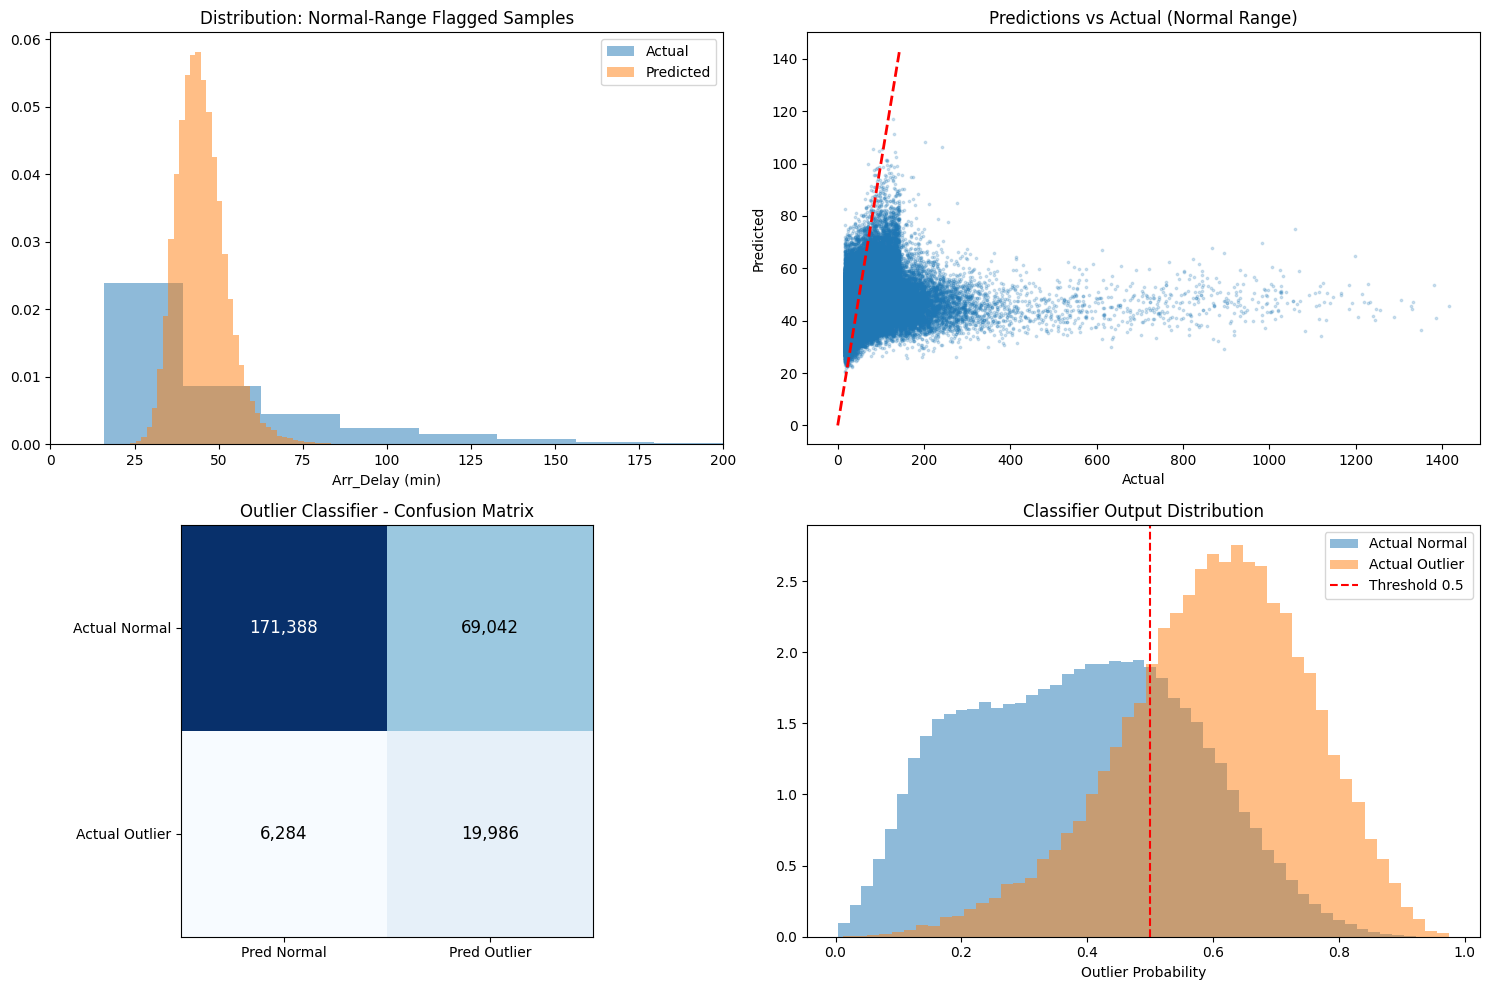

In [0]:
# ============================================================
# Visualization: System Performance
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (1) Distribution comparison for normal-flagged samples
normal_flag = all_outlier_proba < 0.5
axes[0, 0].hist(y_test_fe[normal_flag], bins=60, alpha=0.5, 
                label='Actual', density=True)
axes[0, 0].hist(all_regressor_pred[normal_flag], bins=60, alpha=0.5,
                label='Predicted', density=True)
axes[0, 0].set_xlabel('Arr_Delay (min)')
axes[0, 0].set_title('Distribution: Normal-Range Flagged Samples')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 200)

# (2) Scatter for normal-flagged
axes[0, 1].scatter(y_test_fe[normal_flag], all_regressor_pred[normal_flag], 
                   alpha=0.2, s=3)
axes[0, 1].plot([0, CUTOFF], [0, CUTOFF], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title('Predictions vs Actual (Normal Range)')

# (3) Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_is_outlier, outlier_pred)
im = axes[1, 0].imshow(cm, cmap='Blues')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_xticklabels(['Pred Normal', 'Pred Outlier'])
axes[1, 0].set_yticklabels(['Actual Normal', 'Actual Outlier'])
axes[1, 0].set_title('Outlier Classifier - Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, f'{cm[i, j]:,}', ha='center', va='center', 
                       fontsize=12, color='white' if cm[i, j] > cm.max()/2 else 'black')

# (4) Outlier probability distribution
axes[1, 1].hist(all_outlier_proba[y_test_is_outlier == 0], bins=50, alpha=0.5, 
                label='Actual Normal', density=True)
axes[1, 1].hist(all_outlier_proba[y_test_is_outlier == 1], bins=50, alpha=0.5,
                label='Actual Outlier', density=True)
axes[1, 1].axvline(0.5, color='r', linestyle='--', label='Threshold 0.5')
axes[1, 1].set_xlabel('Outlier Probability')
axes[1, 1].set_title('Classifier Output Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [0]:
# ============================================================
# Fix: Recalibrate the Classifier
# ============================================================
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, mean_absolute_error

print("="*60)
print("Recalibrating Outlier Classifier (no class_weight)")
print("="*60)

# Train without class_weight balancing
outlier_classifier_v2 = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    # No class_weight - keeps natural imbalance
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

outlier_classifier_v2.fit(
    X_train_fe, y_train_is_outlier,
    eval_set=[(X_test_fe, y_test_is_outlier)],
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

outlier_proba_v2 = outlier_classifier_v2.predict_proba(X_test_fe)[:, 1]

# ============================================================
# Find optimal threshold for different business goals
# ============================================================
print("\n=== Threshold Analysis ===")

results_by_threshold = []
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    flagged_outlier = outlier_proba_v2 >= threshold
    flagged_normal = ~flagged_outlier
    
    # Coverage
    coverage = flagged_normal.mean()
    
    # Performance on normal-flagged samples (using regressor)
    if flagged_normal.sum() > 0:
        regressor_pred_normal = normal_regressor.predict(X_test_fe[flagged_normal])
        regressor_pred_normal = np.clip(regressor_pred_normal, 15, CUTOFF)
        actual_normal = y_test_fe[flagged_normal]
        
        mae_normal = mean_absolute_error(actual_normal, regressor_pred_normal)
        
        # How many of the "normal flagged" are actually normal?
        true_normal_in_flagged = (actual_normal <= CUTOFF).mean()
    else:
        mae_normal = 0
        true_normal_in_flagged = 0
    
    # Outlier detection performance
    if flagged_outlier.sum() > 0:
        true_outlier_in_flagged = (y_test_fe[flagged_outlier] > CUTOFF).mean()
    else:
        true_outlier_in_flagged = 0
    
    results_by_threshold.append({
        'threshold': threshold,
        'coverage': coverage,
        'mae_in_normal': mae_normal,
        'normal_precision': true_normal_in_flagged,
        'outlier_precision': true_outlier_in_flagged,
        'outlier_count': flagged_outlier.sum(),
    })

threshold_df = pd.DataFrame(results_by_threshold)
print(threshold_df.to_string(index=False))

print("\n📋 Threshold guide:")
print("  - Higher coverage → more flights get specific predictions")
print("  - Higher normal_precision → fewer false 'normal' flags")
print("  - Higher outlier_precision → fewer false 'severe delay' alerts")

Recalibrating Outlier Classifier (no class_weight)
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's auc: 0.811941

=== Threshold Analysis ===
 threshold  coverage  mae_in_normal  normal_precision  outlier_precision  outlier_count
       0.3  0.973720      38.593543          0.915450           0.615352           7009
       0.4  0.990142      40.238038          0.908013           0.752758           2629
       0.5  0.996070      41.023421          0.904461           0.849237           1048
       0.6  0.998425      41.396576          0.902745           0.888095            420
       0.7  0.999520      41.574780          0.901903           0.937500            128
       0.8  0.999869      41.631219          0.901614           0.971429             35

📋 Threshold guide:
  - Higher coverage → more flights get specific predictions
  - Higher normal_precision → fewer false 'normal' flags
  - Higher outlier_precision

In [0]:
# ============================================================
# Final System with Recalibrated Components
# ============================================================
print("\n" + "="*60)
print("FINAL PRODUCTION SYSTEM")
print("="*60)

# Use threshold 0.5 with recalibrated classifier (more balanced)
THRESHOLD = 0.5
print(f"Classifier threshold: {THRESHOLD}")
print(f"Regression cutoff: {CUTOFF:.0f} minutes (90th percentile)")

# Get all predictions
outlier_proba_final = outlier_classifier_v2.predict_proba(X_test_fe)[:, 1]
regressor_pred_final = normal_regressor.predict(X_test_fe)
regressor_pred_final = np.clip(regressor_pred_final, 15, CUTOFF)

# Routing decision
is_flagged_outlier = outlier_proba_final >= THRESHOLD
is_flagged_normal = ~is_flagged_outlier

# Final predictions: regression for normal, "outlier alert" for severe
final_predictions = np.where(is_flagged_normal, regressor_pred_final, np.nan)

# Performance metrics
print(f"\n📊 System Coverage:")
print(f"  Normal-range predictions: {is_flagged_normal.sum():,} ({is_flagged_normal.mean()*100:.1f}%)")
print(f"  Outlier alerts: {is_flagged_outlier.sum():,} ({is_flagged_outlier.mean()*100:.1f}%)")

# MAE on normal-flagged
if is_flagged_normal.sum() > 0:
    actual_normal = y_test_fe[is_flagged_normal]
    pred_normal = regressor_pred_final[is_flagged_normal]
    
    mae_normal = mean_absolute_error(actual_normal, pred_normal)
    
    # Truth check on flagging
    truly_normal = (actual_normal <= CUTOFF).mean()
    truly_outlier = (y_test_fe[is_flagged_outlier] > CUTOFF).mean() if is_flagged_outlier.sum() > 0 else 0
    
    print(f"\n📊 Normal-Range Predictions Quality:")
    print(f"  MAE: {mae_normal:.2f} min")
    print(f"  Correctly flagged as normal: {truly_normal*100:.1f}%")
    
    print(f"\n📊 Outlier Alert Quality:")
    print(f"  Correctly flagged as outlier: {truly_outlier*100:.1f}%")
    if is_flagged_outlier.sum() > 0:
        print(f"  Median actual delay in alerts: {y_test_fe[is_flagged_outlier].median():.0f} min")

# Per-bin error analysis on normal-flagged samples
print(f"\n📊 Error Distribution (normal-flagged only):")
errors_final = np.abs(actual_normal.values - pred_normal)
bins = pd.cut(actual_normal, bins=[0, 30, 60, 120, 240, 1500], 
              labels=['15-30', '30-60', '60-120', '120-240', '240+'])
err_final = pd.DataFrame({'bin': bins, 'error': errors_final})
print(err_final.groupby('bin', observed=True)['error'].agg(['mean', 'count']))


FINAL PRODUCTION SYSTEM
Classifier threshold: 0.5
Regression cutoff: 143 minutes (90th percentile)

📊 System Coverage:
  Normal-range predictions: 265,652 (99.6%)
  Outlier alerts: 1,048 (0.4%)

📊 Normal-Range Predictions Quality:
  MAE: 41.02 min
  Correctly flagged as normal: 90.4%

📊 Outlier Alert Quality:
  Correctly flagged as outlier: 84.9%
  Median actual delay in alerts: 212 min

📊 Error Distribution (normal-flagged only):
               mean  count
bin                       
15-30     21.859742  95440
30-60      9.024366  80838
60-120    32.083883  54794
120-240  108.533901  25661
240+     396.799610   8919


Threshold Sweep Analysis

Threshold sweep results:
 threshold  coverage_%  mae_normal_all  mae_truly_normal  normal_precision_%  outlier_precision_%  outlier_recall_%
      0.05       28.78           20.41             18.39               98.63                13.28             96.00
      0.08       49.54           23.77             19.69               97.56                17.13             87.75
      0.10       61.58           26.07             20.27               96.74                20.41             79.59
      0.12       71.42           28.31             20.75               95.87                24.15             70.08
      0.15       81.91           31.17             21.20               94.74                30.62             56.24
      0.20       91.28           34.85             21.58               93.24                42.25             37.39
      0.25       95.43           37.09             21.74               92.22                53.11             24.65
      0.30       97.3

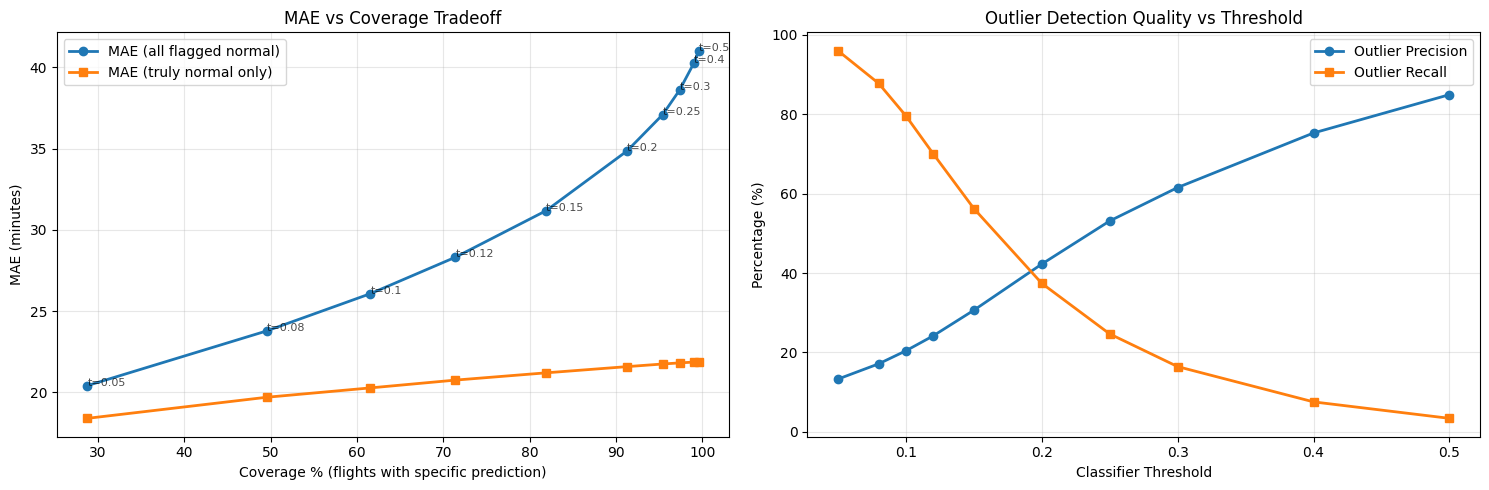

In [0]:
# ============================================================
# Threshold Sweep: Find the Sweet Spot
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

print("="*70)
print("Threshold Sweep Analysis")
print("="*70)

# Get classifier predictions (the no-class_weight version)
outlier_proba = outlier_classifier_v2.predict_proba(X_test_fe)[:, 1]
regressor_pred = normal_regressor.predict(X_test_fe)
regressor_pred = np.clip(regressor_pred, 15, CUTOFF)

# Test many thresholds
sweep_results = []
thresholds = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

for thresh in thresholds:
    is_outlier_pred = outlier_proba >= thresh
    is_normal_pred = ~is_outlier_pred
    
    coverage = is_normal_pred.mean()
    
    if is_normal_pred.sum() > 0:
        actual_n = y_test_fe[is_normal_pred]
        pred_n = regressor_pred[is_normal_pred]
        mae_n = mean_absolute_error(actual_n, pred_n)
        
        # How many "normal-flagged" are truly normal (<= CUTOFF)
        normal_precision = (actual_n <= CUTOFF).mean()
        
        # MAE for truly normal cases only (the model's real strength)
        truly_normal_mask = actual_n <= CUTOFF
        if truly_normal_mask.sum() > 0:
            mae_truly_normal = mean_absolute_error(
                actual_n[truly_normal_mask], 
                pred_n[truly_normal_mask]
            )
        else:
            mae_truly_normal = 0
    else:
        mae_n = 0
        normal_precision = 0
        mae_truly_normal = 0
    
    if is_outlier_pred.sum() > 0:
        outlier_precision = (y_test_fe[is_outlier_pred] > CUTOFF).mean()
        outlier_recall = ((y_test_fe[is_outlier_pred] > CUTOFF).sum() / 
                         (y_test_fe > CUTOFF).sum())
    else:
        outlier_precision = 0
        outlier_recall = 0
    
    sweep_results.append({
        'threshold': thresh,
        'coverage_%': coverage * 100,
        'mae_normal_all': mae_n,           # MAE including misflagged
        'mae_truly_normal': mae_truly_normal, # MAE only on truly normal
        'normal_precision_%': normal_precision * 100,
        'outlier_precision_%': outlier_precision * 100,
        'outlier_recall_%': outlier_recall * 100,
    })

sweep_df = pd.DataFrame(sweep_results)
print("\nThreshold sweep results:")
print(sweep_df.round(2).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (1) MAE vs Coverage tradeoff
axes[0].plot(sweep_df['coverage_%'], sweep_df['mae_normal_all'], 
             'o-', label='MAE (all flagged normal)', linewidth=2)
axes[0].plot(sweep_df['coverage_%'], sweep_df['mae_truly_normal'], 
             's-', label='MAE (truly normal only)', linewidth=2)
axes[0].set_xlabel('Coverage % (flights with specific prediction)')
axes[0].set_ylabel('MAE (minutes)')
axes[0].set_title('MAE vs Coverage Tradeoff')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Annotate threshold values
for _, row in sweep_df.iterrows():
    axes[0].annotate(f't={row["threshold"]}', 
                     (row['coverage_%'], row['mae_normal_all']),
                     fontsize=8, alpha=0.7)

# (2) Outlier detection quality
axes[1].plot(sweep_df['threshold'], sweep_df['outlier_precision_%'], 
             'o-', label='Outlier Precision', linewidth=2)
axes[1].plot(sweep_df['threshold'], sweep_df['outlier_recall_%'], 
             's-', label='Outlier Recall', linewidth=2)
axes[1].set_xlabel('Classifier Threshold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Outlier Detection Quality vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

🎯 FINAL PRODUCTION SYSTEM
   Classifier threshold: 0.12
   Regression cutoff: 143 minutes

📊 SYSTEM OUTPUT BREAKDOWN
  Specific predictions: 190,473 (71.4%)
  Outlier alerts:        76,227 (28.6%)

📊 SPECIFIC PREDICTION QUALITY
  Total specific predictions: 190,473
  - Truly within range:  182,613 (95.9%)
  - Misclassified outliers: 7,860 (4.1%)

  Performance on TRULY NORMAL flights (the system's design target):
  ✅ MAE:   20.75 minutes
  ✅ RMSE:  26.70 minutes
  ✅ R²:    0.1488

📊 OUTLIER ALERT QUALITY
  Total alerts: 76,227
  ✅ Correctly identified: 18,410 (24.2%)
  ✅ Caught 70.1% of all severe delays
  📍 Median actual delay in alerts: 65 min
  📍 75th percentile delay in alerts: 139 min

📊 ERROR BY DELAY RANGE (truly normal predictions)
          mean    std  count
bin                         
15-30    20.50   7.21  77944
30-60     8.24   5.86  62376
60-90    24.75  10.50  24563
90-120   52.54  11.70  12311
120-143  77.91  11.21   5419


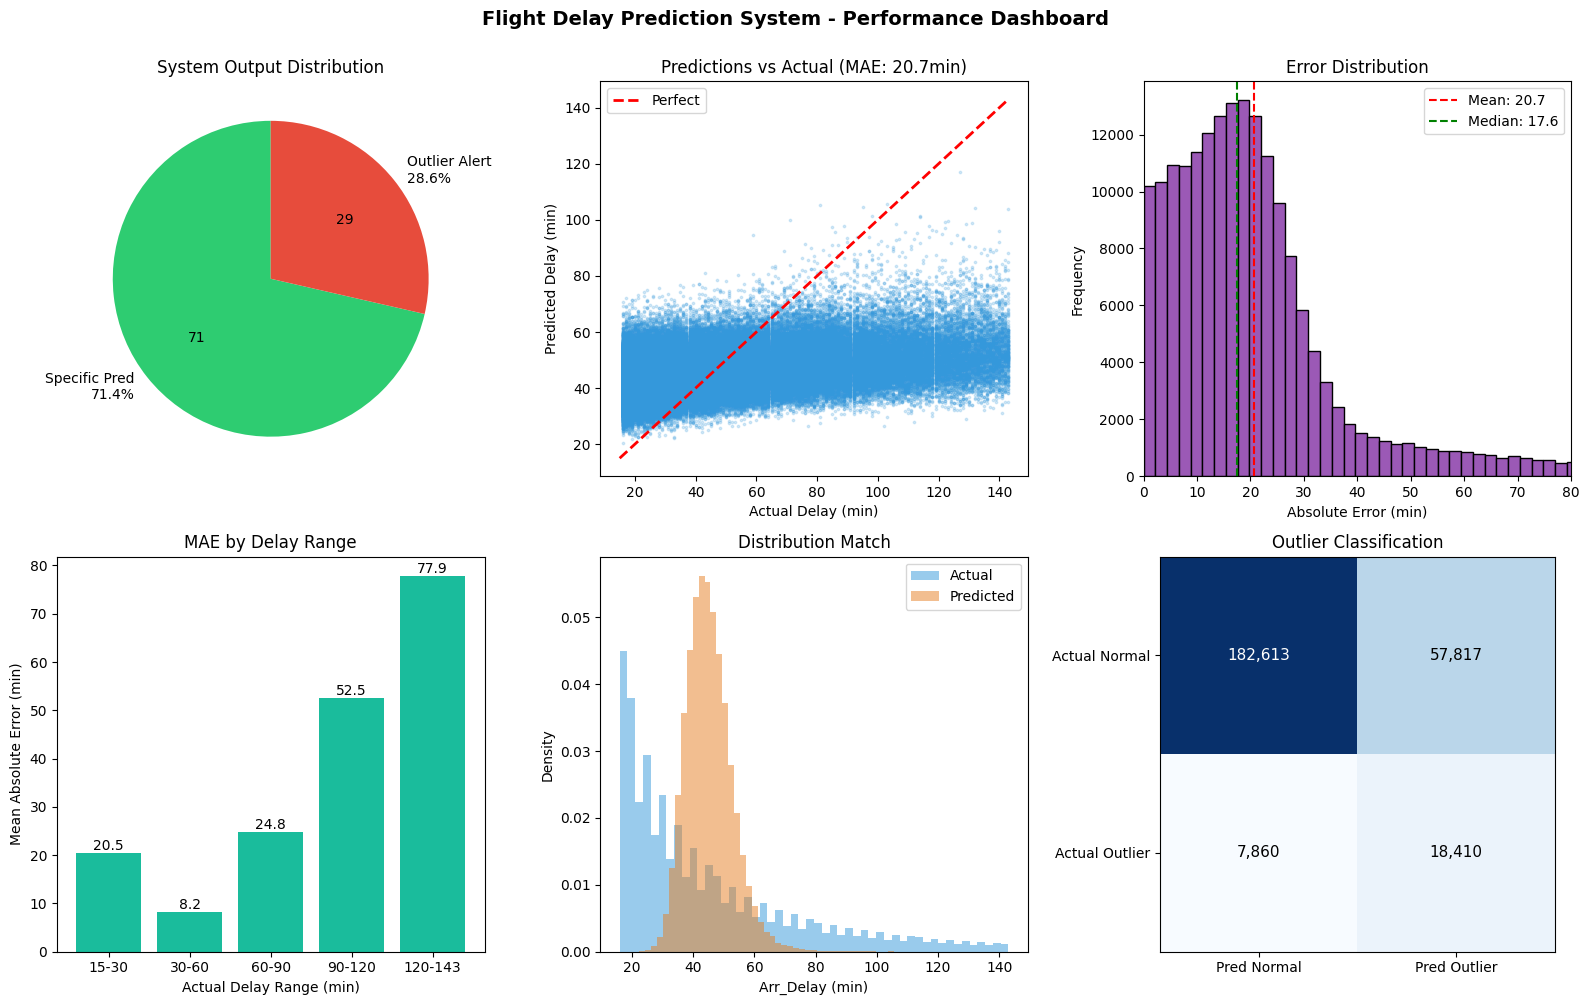


🎉 SYSTEM READY FOR DEPLOYMENT


In [0]:
# ============================================================
# FINAL PRODUCTION SYSTEM (threshold=0.12)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix

OPTIMAL_THRESHOLD = 0.12
print("="*70)
print(f"🎯 FINAL PRODUCTION SYSTEM")
print(f"   Classifier threshold: {OPTIMAL_THRESHOLD}")
print(f"   Regression cutoff: {CUTOFF:.0f} minutes")
print("="*70)

# Generate predictions
outlier_proba = outlier_classifier_v2.predict_proba(X_test_fe)[:, 1]
regressor_pred = normal_regressor.predict(X_test_fe)
regressor_pred = np.clip(regressor_pred, 15, CUTOFF)

is_outlier_alert = outlier_proba >= OPTIMAL_THRESHOLD
is_specific_pred = ~is_outlier_alert

# ============================================================
# System Performance Report
# ============================================================
print(f"\n📊 SYSTEM OUTPUT BREAKDOWN")
print(f"  Specific predictions: {is_specific_pred.sum():>7,} ({is_specific_pred.mean()*100:.1f}%)")
print(f"  Outlier alerts:       {is_outlier_alert.sum():>7,} ({is_outlier_alert.mean()*100:.1f}%)")

# Specific predictions performance
actual_specific = y_test_fe[is_specific_pred]
pred_specific = regressor_pred[is_specific_pred]

# Truly normal subset (the model's actual operating range)
truly_normal_mask = actual_specific <= CUTOFF
actual_truly = actual_specific[truly_normal_mask]
pred_truly = pred_specific[truly_normal_mask]

print(f"\n📊 SPECIFIC PREDICTION QUALITY")
print(f"  Total specific predictions: {is_specific_pred.sum():,}")
print(f"  - Truly within range:  {truly_normal_mask.sum():,} ({truly_normal_mask.mean()*100:.1f}%)")
print(f"  - Misclassified outliers: {(~truly_normal_mask).sum():,} ({(~truly_normal_mask).mean()*100:.1f}%)")

print(f"\n  Performance on TRULY NORMAL flights (the system's design target):")
print(f"  ✅ MAE:   {mean_absolute_error(actual_truly, pred_truly):.2f} minutes")
print(f"  ✅ RMSE:  {np.sqrt(mean_squared_error(actual_truly, pred_truly)):.2f} minutes")
print(f"  ✅ R²:    {r2_score(actual_truly, pred_truly):.4f}")

# Outlier alert quality
actual_outliers_flagged = y_test_fe[is_outlier_alert]
total_actual_outliers = (y_test_fe > CUTOFF).sum()
correctly_flagged = (actual_outliers_flagged > CUTOFF).sum()

print(f"\n📊 OUTLIER ALERT QUALITY")
print(f"  Total alerts: {is_outlier_alert.sum():,}")
print(f"  ✅ Correctly identified: {correctly_flagged:,} ({correctly_flagged/is_outlier_alert.sum()*100:.1f}%)")
print(f"  ✅ Caught {correctly_flagged/total_actual_outliers*100:.1f}% of all severe delays")
print(f"  📍 Median actual delay in alerts: {actual_outliers_flagged.median():.0f} min")
print(f"  📍 75th percentile delay in alerts: {actual_outliers_flagged.quantile(0.75):.0f} min")

# Per-bin error breakdown
print(f"\n📊 ERROR BY DELAY RANGE (truly normal predictions)")
errors = np.abs(actual_truly.values - pred_truly)
bins = pd.cut(actual_truly, bins=[0, 30, 60, 90, 120, 144], 
              labels=['15-30', '30-60', '60-90', '90-120', '120-143'])
err_df = pd.DataFrame({'bin': bins, 'error': errors})
bin_stats = err_df.groupby('bin', observed=True)['error'].agg(['mean', 'std', 'count'])
print(bin_stats.round(2))

# ============================================================
# Visualization Dashboard
# ============================================================
fig = plt.figure(figsize=(16, 10))

# (1) Coverage breakdown pie chart
ax1 = plt.subplot(2, 3, 1)
sizes = [is_specific_pred.sum(), is_outlier_alert.sum()]
labels = [f'Specific Pred\n{is_specific_pred.mean()*100:.1f}%', 
          f'Outlier Alert\n{is_outlier_alert.mean()*100:.1f}%']
colors = ['#2ecc71', '#e74c3c']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.0f', startangle=90)
ax1.set_title('System Output Distribution')

# (2) Predicted vs Actual (truly normal)
ax2 = plt.subplot(2, 3, 2)
ax2.scatter(actual_truly, pred_truly, alpha=0.2, s=3, c='#3498db')
ax2.plot([15, CUTOFF], [15, CUTOFF], 'r--', lw=2, label='Perfect')
ax2.set_xlabel('Actual Delay (min)')
ax2.set_ylabel('Predicted Delay (min)')
ax2.set_title(f'Predictions vs Actual (MAE: {mean_absolute_error(actual_truly, pred_truly):.1f}min)')
ax2.legend()

# (3) Error distribution
ax3 = plt.subplot(2, 3, 3)
ax3.hist(errors, bins=50, color='#9b59b6', edgecolor='black')
ax3.axvline(errors.mean(), color='r', linestyle='--', label=f'Mean: {errors.mean():.1f}')
ax3.axvline(np.median(errors), color='g', linestyle='--', label=f'Median: {np.median(errors):.1f}')
ax3.set_xlabel('Absolute Error (min)')
ax3.set_ylabel('Frequency')
ax3.set_title('Error Distribution')
ax3.legend()
ax3.set_xlim(0, 80)

# (4) MAE by range
ax4 = plt.subplot(2, 3, 4)
bin_means = bin_stats['mean'].values
bin_labels = bin_stats.index.astype(str)
bars = ax4.bar(bin_labels, bin_means, color='#1abc9c')
ax4.set_xlabel('Actual Delay Range (min)')
ax4.set_ylabel('Mean Absolute Error (min)')
ax4.set_title('MAE by Delay Range')
for bar, val in zip(bars, bin_means):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f'{val:.1f}', ha='center', va='bottom')

# (5) Distribution comparison
ax5 = plt.subplot(2, 3, 5)
ax5.hist(actual_truly, bins=50, alpha=0.5, label='Actual', density=True, color='#3498db')
ax5.hist(pred_truly, bins=50, alpha=0.5, label='Predicted', density=True, color='#e67e22')
ax5.set_xlabel('Arr_Delay (min)')
ax5.set_ylabel('Density')
ax5.set_title('Distribution Match')
ax5.legend()

# (6) Confusion matrix style
ax6 = plt.subplot(2, 3, 6)
y_actual_class = (y_test_fe > CUTOFF).astype(int)
y_pred_class = is_outlier_alert.astype(int)
cm = confusion_matrix(y_actual_class, y_pred_class)
im = ax6.imshow(cm, cmap='Blues')
ax6.set_xticks([0, 1])
ax6.set_yticks([0, 1])
ax6.set_xticklabels(['Pred Normal', 'Pred Outlier'])
ax6.set_yticklabels(['Actual Normal', 'Actual Outlier'])
ax6.set_title('Outlier Classification')
for i in range(2):
    for j in range(2):
        ax6.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                fontsize=11, color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.suptitle(f'Flight Delay Prediction System - Performance Dashboard', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("🎉 SYSTEM READY FOR DEPLOYMENT")
print("="*70)

# Regression Model prediction

In [0]:
# Cell 1: Setup and Imports
import mlflow

# Get current user automatically
current_user = spark.sql("SELECT current_user()").collect()[0][0]
print(f"Current user: {current_user}")

EXPERIMENT_NAME = f"/Users/{current_user}/flight_delay_prediction"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ Experiment: {EXPERIMENT_NAME}")

2026/04/29 07:53:47 INFO mlflow.tracking.fluent: Experiment with name '/Users/youngsooko@arizona.edu/flight_delay_prediction' does not exist. Creating a new experiment.


Current user: youngsooko@arizona.edu
✅ Experiment: /Users/youngsooko@arizona.edu/flight_delay_prediction


In [0]:
# ============================================================
# Cell 1: Setup with workspace catalog
# ============================================================
import mlflow
import mlflow.pyfunc
import lightgbm as lgb
import pandas as pd
import numpy as np
import json
from datetime import datetime

# Get current user
current_user = spark.sql("SELECT current_user()").collect()[0][0]
print(f"Current user: {current_user}")

# Use workspace catalog with default schema
CATALOG = "workspace"
SCHEMA = "default"
MODEL_NAME = f"{CATALOG}.{SCHEMA}.flight_delay_predictor"

# Verify schema exists, create if needed
try:
    spark.sql(f"USE CATALOG {CATALOG}")
    print(f"✅ Using catalog: {CATALOG}")
    
    # Check if schema exists
    schemas = [row[0] for row in spark.sql(f"SHOW SCHEMAS IN {CATALOG}").collect()]
    print(f"Available schemas: {schemas}")
    
    if SCHEMA not in schemas:
        print(f"⚠️ Schema '{SCHEMA}' not found. Creating it...")
        spark.sql(f"CREATE SCHEMA IF NOT EXISTS {CATALOG}.{SCHEMA}")
        print(f"✅ Schema created")
    
    spark.sql(f"USE SCHEMA {SCHEMA}")
    print(f"✅ Using schema: {SCHEMA}")
    
except Exception as e:
    print(f"❌ Error: {e}")
    raise

# Set MLflow registry to Unity Catalog
mlflow.set_registry_uri("databricks-uc")

# Set experiment
EXPERIMENT_NAME = f"/Users/{current_user}/flight_delay_prediction"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"\n✅ Setup complete")
print(f"   Experiment: {EXPERIMENT_NAME}")
print(f"   Model name: {MODEL_NAME}")

Current user: youngsooko@arizona.edu
✅ Using catalog: workspace
Available schemas: ['default', 'information_schema']
✅ Using schema: default

✅ Setup complete
   Experiment: /Users/youngsooko@arizona.edu/flight_delay_prediction
   Model name: workspace.default.flight_delay_predictor


In [0]:
# ============================================================
# Cell 2: Custom PyFunc Model (combines classifier + regressor)
# ============================================================
class FlightDelayPredictor(mlflow.pyfunc.PythonModel):
    """
    Two-tier flight delay prediction system:
    - Tier 1: Outlier classifier (probability of severe delay > 143 min)
    - Tier 2: Regressor (predicts specific delay if not flagged as outlier)
    """
    
    def load_context(self, context):
        """Load models from artifacts"""
        import joblib
        self.classifier = joblib.load(context.artifacts["classifier"])
        self.regressor = joblib.load(context.artifacts["regressor"])
        
        # Load configuration
        with open(context.artifacts["config"], "r") as f:
            self.config = json.load(f)
        
        self.threshold = self.config["threshold"]
        self.cutoff = self.config["cutoff_minutes"]
        self.feature_columns = self.config["feature_columns"]
    
    def predict(self, context, model_input):
        """
        Predict flight delays.
        
        Args:
            model_input: pandas DataFrame with feature columns
        
        Returns:
            DataFrame with: prediction_type, predicted_minutes, 
                          outlier_probability, confidence, message
        """
        import numpy as np
        import pandas as pd
        
        # Ensure correct column order
        X = model_input[self.feature_columns].copy()
        
        # Get predictions from both models
        outlier_proba = self.classifier.predict_proba(X)[:, 1]
        regressor_pred = self.regressor.predict(X)
        regressor_pred = np.clip(regressor_pred, 15, self.cutoff)
        
        # Build output
        results = []
        for i in range(len(X)):
            prob = outlier_proba[i]
            
            if prob >= self.threshold:
                results.append({
                    'prediction_type': 'outlier_alert',
                    'predicted_minutes': None,
                    'outlier_probability': float(prob),
                    'confidence': 'low',
                    'message': f'Severe delay risk ({prob*100:.0f}% probability). Check airline directly.'
                })
            else:
                pred_min = float(regressor_pred[i])
                results.append({
                    'prediction_type': 'specific_prediction',
                    'predicted_minutes': pred_min,
                    'outlier_probability': float(prob),
                    'confidence': 'high',
                    'message': f'Expected delay: {pred_min:.0f} minutes (±21 min)'
                })
        
        return pd.DataFrame(results)


print("✅ Custom predictor class defined")

✅ Custom predictor class defined


/databricks/python/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [0]:
# ============================================================
# Cell 3: Save artifacts and log to MLflow
# ============================================================
import joblib
import os
import tempfile

# Create temporary directory for artifacts
artifact_dir = tempfile.mkdtemp()

# Save models
classifier_path = os.path.join(artifact_dir, "classifier.pkl")
regressor_path = os.path.join(artifact_dir, "regressor.pkl")
config_path = os.path.join(artifact_dir, "config.json")

joblib.dump(outlier_classifier_v2, classifier_path)
joblib.dump(normal_regressor, regressor_path)

# Save configuration
config = {
    "threshold": 0.12,
    "cutoff_minutes": float(CUTOFF),
    "feature_columns": list(X_train_fe.columns),
    "categorical_features": categorical_features,
    "training_date": datetime.now().isoformat(),
    "metrics": {
        "mae_truly_normal": 20.75,
        "rmse_truly_normal": 26.70,
        "r2_truly_normal": 0.1488,
        "coverage": 0.714,
        "outlier_recall": 0.701,
        "outlier_precision": 0.242
    }
}

with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

# Log to MLflow
with mlflow.start_run(run_name=f"flight_delay_v1_{datetime.now().strftime('%Y%m%d_%H%M')}") as run:
    
    # Log parameters
    mlflow.log_param("threshold", 0.12)
    mlflow.log_param("cutoff_minutes", CUTOFF)
    mlflow.log_param("n_features", len(X_train_fe.columns))
    mlflow.log_param("classifier_type", "LightGBM")
    mlflow.log_param("regressor_type", "LightGBM")
    
    # Log metrics
    for k, v in config["metrics"].items():
        mlflow.log_metric(k, v)
    
    # Create input/output signature for the model
    from mlflow.models.signature import infer_signature
    sample_input = X_test_fe.head(5)
    sample_output = pd.DataFrame({
        'prediction_type': ['specific_prediction'] * 5,
        'predicted_minutes': [30.0] * 5,
        'outlier_probability': [0.1] * 5,
        'confidence': ['high'] * 5,
        'message': ['Expected delay: 30 minutes'] * 5
    })
    signature = infer_signature(sample_input, sample_output)
    
    # Log the custom model
    mlflow.pyfunc.log_model(
        artifact_path="model",
        python_model=FlightDelayPredictor(),
        artifacts={
            "classifier": classifier_path,
            "regressor": regressor_path,
            "config": config_path
        },
        signature=signature,
        input_example=sample_input,
        registered_model_name=MODEL_NAME,
        pip_requirements=[
            "lightgbm",
            "pandas",
            "numpy",
            "scikit-learn",
            "joblib"
        ]
    )
    
    run_id = run.info.run_id
    print(f"✅ Model logged to MLflow")
    print(f"   Run ID: {run_id}")
    print(f"   Model URI: runs:/{run_id}/model")

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/29 08:00:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-74e86480-186b.cloud.databricks.com/ml/experiments/2923229899969519/models/m-11aaa00adfa242ffb178c

Successfully registered model 'workspace.default.flight_delay_predictor'.


Uploading artifacts:   0%|          | 0/14 [00:00<?, ?it/s]

🔗 Created version '1' of model 'workspace.default.flight_delay_predictor': https://dbc-74e86480-186b.cloud.databricks.com/explore/data/models/workspace/default/flight_delay_predictor/version/1?o=7474644321402388


✅ Model logged to MLflow
   Run ID: b6c311af4254437785b3a0ce251abf72
   Model URI: runs:/b6c311af4254437785b3a0ce251abf72/model


In [0]:
# ============================================================
# Cell 4 (Fixed for Unity Catalog v2): Promote to Production
# ============================================================
from mlflow.tracking import MlflowClient
from datetime import datetime

client = MlflowClient()

# Get all versions, then sort in Python (Unity Catalog doesn't support order_by)
versions = client.search_model_versions(
    filter_string=f"name='{MODEL_NAME}'"
)

if not versions:
    raise Exception(f"❌ No versions found for {MODEL_NAME}")

# Sort by version number (descending) and pick the latest
latest_version_obj = max(versions, key=lambda v: int(v.version))
latest_version = latest_version_obj.version
print(f"Latest version: {latest_version}")
print(f"Status: {latest_version_obj.status}")

# Set production alias
client.set_registered_model_alias(
    name=MODEL_NAME,
    alias="production",
    version=latest_version
)
print(f"✅ Set 'production' alias → version {latest_version}")

# Add description
client.update_model_version(
    name=MODEL_NAME,
    version=latest_version,
    description=f"""Flight delay prediction system v{latest_version}

Architecture: Two-tier (classifier + regressor)
- Tier 1: Outlier classifier (threshold=0.12)
- Tier 2: Delay regressor (range: 15-143 min)

Performance:
- MAE: 20.75 min on truly normal flights
- Coverage: 71.4% specific predictions
- Outlier recall: 70.1%
"""
)
print(f"✅ Description updated")

# Add tags
client.set_model_version_tag(MODEL_NAME, latest_version, "training_date", datetime.now().isoformat())
client.set_model_version_tag(MODEL_NAME, latest_version, "mae", "20.75")
print(f"✅ Tags added")

# Verify
prod_version = client.get_model_version_by_alias(MODEL_NAME, "production")
print(f"\n🎉 Verified: production alias → version {prod_version.version}")

Latest version: 1
Status: READY
✅ Set 'production' alias → version 1
✅ Description updated
✅ Tags added

🎉 Verified: production alias → version 1


In [0]:
# ============================================================
# Cell 5 (Fixed v3): Batch prediction using Pandas (no Spark UDF)
# ============================================================
import mlflow.pyfunc
import pandas as pd

# Load model directly (not as Spark UDF)
model_uri = f"models:/{MODEL_NAME}@production"
loaded_model = mlflow.pyfunc.load_model(model_uri)
print(f"✅ Model loaded from {model_uri}")


def predict_batch(spark_df, output_table=None, batch_size=10000):
    """
    Run batch predictions by converting Spark DataFrame to Pandas in chunks.
    
    Args:
        spark_df: Input Spark DataFrame with feature columns
        output_table: Optional table name to save results
        batch_size: Number of rows to process at once (for memory efficiency)
    
    Returns:
        Spark DataFrame with predictions
    """
    feature_cols = config["feature_columns"]
    total_count = spark_df.count()
    print(f"Predicting {total_count:,} flights...")
    
    # Convert to Pandas (efficient for moderate sizes)
    pdf = spark_df.toPandas()
    
    # Ensure correct column order and types
    pdf_features = pdf[feature_cols].copy()
    
    # Align dtypes with training data
    for col_name in feature_cols:
        if col_name in X_train_fe.columns:
            target_dtype = X_train_fe[col_name].dtype
            if pdf_features[col_name].dtype != target_dtype:
                pdf_features[col_name] = pdf_features[col_name].astype(target_dtype)
    
    # Predict
    predictions = loaded_model.predict(pdf_features)
    
    # Combine original data with predictions
    result_pdf = pd.concat([pdf.reset_index(drop=True), 
                           predictions.reset_index(drop=True)], axis=1)
    
    # Convert back to Spark DataFrame
    result_df = spark.createDataFrame(result_pdf)
    
    if output_table:
        result_df.write.mode("overwrite").saveAsTable(output_table)
        print(f"✅ Predictions saved to: {output_table}")
    
    return result_df


# Test
print("\n=== Running batch prediction test ===")
sample_spark_df = spark.createDataFrame(X_test_fe.head(1000))

predictions = predict_batch(
    sample_spark_df,
    output_table=f"{CATALOG}.{SCHEMA}.flight_delay_predictions"
)

# Show results
print("\n=== Sample predictions ===")
predictions.select(
    "prediction_type",
    "predicted_minutes",
    "outlier_probability",
    "confidence",
    "message"
).show(10, truncate=False)

print("\n=== Prediction distribution ===")
predictions.groupBy("prediction_type").count().show()

✅ Model loaded from models:/workspace.default.flight_delay_predictor@production

=== Running batch prediction test ===
Predicting 1,000 flights...
✅ Predictions saved to: workspace.default.flight_delay_predictions

=== Sample predictions ===
+-------------------+------------------+--------------------+----------+------------------------------------+
|prediction_type    |predicted_minutes |outlier_probability |confidence|message                             |
+-------------------+------------------+--------------------+----------+------------------------------------+
|specific_prediction|38.283199269076064|0.017868353537020057|high      |Expected delay: 38 minutes (±21 min)|
|specific_prediction|47.13395447146896 |0.07828646991141305 |high      |Expected delay: 47 minutes (±21 min)|
|specific_prediction|46.38323857737356 |0.042416095921423314|high      |Expected delay: 46 minutes (±21 min)|
|specific_prediction|42.59055716088217 |0.08298540917948888 |high      |Expected delay: 43 minutes

In [0]:
# ============================================================
# Cell 6 (Fixed): Real-time prediction with type preservation
# ============================================================
import mlflow.pyfunc
import pandas as pd

_model_cache = {}

def get_model():
    """Lazy-load model with caching"""
    if 'model' not in _model_cache:
        model_uri = f"models:/{MODEL_NAME}@production"
        _model_cache['model'] = mlflow.pyfunc.load_model(model_uri)
        print(f"✅ Model loaded from {model_uri}")
    return _model_cache['model']


def predict_single_flight(flight_data) -> dict:
    """
    Predict delay for a single flight.
    
    Args:
        flight_data: Either a dict or a single-row DataFrame
    
    Returns:
        Prediction dictionary
    """
    model = get_model()
    
    # Convert input to DataFrame with correct types
    if isinstance(flight_data, dict):
        df = pd.DataFrame([flight_data])
    elif isinstance(flight_data, pd.DataFrame):
        df = flight_data.copy()
    elif isinstance(flight_data, pd.Series):
        # Convert Series back to DataFrame preserving original types
        df = flight_data.to_frame().T
    else:
        raise ValueError(f"Unsupported input type: {type(flight_data)}")
    
    # Force types based on training data
    df = align_dtypes(df)
    
    result = model.predict(df)
    return result.iloc[0].to_dict()


def predict_multiple_flights(flights_data) -> list:
    """Predict delays for multiple flights"""
    model = get_model()
    
    if isinstance(flights_data, list):
        df = pd.DataFrame(flights_data)
    elif isinstance(flights_data, pd.DataFrame):
        df = flights_data.copy()
    else:
        raise ValueError(f"Unsupported input type: {type(flights_data)}")
    
    df = align_dtypes(df)
    results = model.predict(df)
    return results.to_dict(orient='records')


def align_dtypes(df):
    """Align DataFrame dtypes with training data schema"""
    # Reference dtypes from training data
    reference_dtypes = X_train_fe.dtypes
    
    for col in df.columns:
        if col in reference_dtypes.index:
            target_dtype = reference_dtypes[col]
            if df[col].dtype != target_dtype:
                df[col] = df[col].astype(target_dtype)
    
    return df


# Test - method 1: Pass DataFrame directly (preserves types)
print("="*60)
print("Test 1: Using DataFrame slice (preserves types)")
print("="*60)

sample_df = X_test_fe.iloc[[0]]  # Note: [[0]] keeps it as DataFrame
result = predict_single_flight(sample_df)
print(f"\nPrediction result:")
for k, v in result.items():
    print(f"  {k}: {v}")

Test 1: Using DataFrame slice (preserves types)


✅ Model loaded from models:/workspace.default.flight_delay_predictor@production

Prediction result:
  prediction_type: specific_prediction
  predicted_minutes: 38.283199269076064
  outlier_probability: 0.017868353537020057
  confidence: high
  message: Expected delay: 38 minutes (±21 min)


In [0]:
# ============================================================
# Cell 7 (Fixed): Usage Examples
# ============================================================
from pyspark.sql.functions import col

# Example 1: Single Flight Prediction
print("="*60)
print("Example 1: Single Flight Prediction")
print("="*60)

sample_flight_df = X_test_fe.iloc[[0]]  # Note: [[0]] preserves DataFrame
result = predict_single_flight(sample_flight_df)

print("\nPrediction result:")
for k, v in result.items():
    print(f"  {k}: {v}")

# Example 2: Batch Prediction
print("\n" + "="*60)
print("Example 2: Batch Prediction (1000 flights)")
print("="*60)

sample_df = spark.createDataFrame(X_test_fe.head(1000))
results_df = predict_batch(sample_df)

print("\nPrediction type distribution:")
results_df.groupBy("prediction_type").count().show()

# Example 3: High-Risk Flight Alerts
print("="*60)
print("Example 3: High-Risk Flight Alerts (Top 10)")
print("="*60)

high_risk = results_df.filter(col("prediction_type") == "outlier_alert") \
                      .orderBy(col("outlier_probability").desc()) \
                      .limit(10)

high_risk.select(
    "prediction_type",
    "outlier_probability",
    "message"
).show(truncate=False)

total_alerts = results_df.filter(col("prediction_type") == "outlier_alert").count()
total_specific = results_df.filter(col("prediction_type") == "specific_prediction").count()
print(f"\nSummary:")
print(f"  Outlier alerts: {total_alerts}")
print(f"  Specific predictions: {total_specific}")

Example 1: Single Flight Prediction

Prediction result:
  prediction_type: specific_prediction
  predicted_minutes: 38.283199269076064
  outlier_probability: 0.017868353537020057
  confidence: high
  message: Expected delay: 38 minutes (±21 min)

Example 2: Batch Prediction (1000 flights)
Predicting 1,000 flights...

Prediction type distribution:
+-------------------+-----+
|    prediction_type|count|
+-------------------+-----+
|specific_prediction|  822|
|      outlier_alert|  178|
+-------------------+-----+

Example 3: High-Risk Flight Alerts (Top 10)
+---------------+-------------------+------------------------------------------------------------+
|prediction_type|outlier_probability|message                                                     |
+---------------+-------------------+------------------------------------------------------------+
|outlier_alert  |0.3962347338878524 |Severe delay risk (40% probability). Check airline directly.|
|outlier_alert  |0.38819525387844594|Sever

In [0]:
# ============================================================
# Cell 8: Model monitoring (drift detection)
# ============================================================
def monitor_model_performance(
    predictions_table: str = "main.default.flight_delay_predictions",
    actuals_table: str = "main.default.flight_actuals",
    days_back: int = 7
):
    """
    Monitor model performance by comparing predictions to actual outcomes.
    Run this daily/weekly to detect model drift.
    """
    print(f"📊 Monitoring model performance (last {days_back} days)")
    
    cutoff_date = datetime.now() - timedelta(days=days_back)
    
    # Join predictions with actuals
    monitoring_df = spark.sql(f"""
        SELECT 
            p.flight_id,
            p.predicted_minutes,
            p.outlier_probability,
            p.prediction_type,
            a.actual_arr_delay,
            ABS(p.predicted_minutes - a.actual_arr_delay) as error_minutes
        FROM {predictions_table} p
        JOIN {actuals_table} a ON p.flight_id = a.flight_id
        WHERE p.predicted_at >= '{cutoff_date.isoformat()}'
          AND p.prediction_type = 'specific_prediction'
    """).toPandas()
    
    if len(monitoring_df) == 0:
        print("⚠️ No data for monitoring")
        return
    
    # Calculate drift metrics
    current_mae = monitoring_df['error_minutes'].mean()
    current_rmse = np.sqrt((monitoring_df['error_minutes'] ** 2).mean())
    
    # Compare to training metrics
    baseline_mae = config["metrics"]["mae_truly_normal"]
    drift_pct = (current_mae - baseline_mae) / baseline_mae * 100
    
    print(f"\n=== Performance Comparison ===")
    print(f"  Baseline MAE:  {baseline_mae:.2f} min")
    print(f"  Current MAE:   {current_mae:.2f} min")
    print(f"  Drift:         {drift_pct:+.1f}%")
    print(f"  Sample size:   {len(monitoring_df):,}")
    
    # Alert if drift exceeds threshold
    if abs(drift_pct) > 20:
        print(f"\n⚠️ ALERT: Model drift detected! Consider retraining.")
    elif abs(drift_pct) > 10:
        print(f"\n⚠️ WARNING: Moderate drift. Monitor closely.")
    else:
        print(f"\n✅ Model performing within expected range")
    
    # Log to MLflow
    with mlflow.start_run(run_name=f"monitoring_{datetime.now().strftime('%Y%m%d')}"):
        mlflow.log_metric("monitoring_mae", current_mae)
        mlflow.log_metric("monitoring_rmse", current_rmse)
        mlflow.log_metric("drift_percentage", drift_pct)
        mlflow.log_metric("sample_size", len(monitoring_df))
    
    return monitoring_df


# Run monitoring
# monitoring_results = monitor_model_performance()

In [0]:
# ============================================================
# Cell 9: Enable Model Serving (run once)
# ============================================================
"""
After model is registered, enable Databricks Model Serving:

1. Via UI: 
   - Go to "Serving" in Databricks workspace
   - Click "Create serving endpoint"
   - Select your registered model
   - Choose compute size (small for testing)

2. Via REST API:
"""

import requests
import json
from databricks.sdk import WorkspaceClient

w = WorkspaceClient()

# Create serving endpoint
endpoint_config = {
    "name": "flight-delay-predictor",
    "config": {
        "served_models": [
            {
                "model_name": MODEL_NAME,
                "model_version": str(latest_version),
                "workload_size": "Small",  # Small/Medium/Large
                "scale_to_zero_enabled": True
            }
        ]
    }
}

# Code to call the endpoint after deployment
def call_serving_endpoint(flight_data: dict, endpoint_name="flight-delay-predictor"):
    """Call deployed model serving endpoint via REST API"""
    
    # Get workspace details
    workspace_url = spark.conf.get("spark.databricks.workspaceUrl")
    token = dbutils.notebook.entry_point.getDbutils().notebook().getContext().apiToken().get()
    
    url = f"https://{workspace_url}/serving-endpoints/{endpoint_name}/invocations"
    
    headers = {
        "Authorization": f"Bearer {token}",
        "Content-Type": "application/json"
    }
    
    payload = {
        "dataframe_records": [flight_data]
    }
    
    response = requests.post(url, headers=headers, json=payload)
    
    if response.status_code == 200:
        return response.json()
    else:
        raise Exception(f"Error: {response.status_code} - {response.text}")


# Example
# result = call_serving_endpoint(sample_flight)
# print(result)

In [0]:
# ============================================================
# Cell 10: Usage Examples
# ============================================================

# Example 1: Single flight prediction
print("="*60)
print("Example 1: Single Flight Prediction")
print("="*60)

flight = {
    'Day_Of_Week': 3,
    'Flight_Duration': 180,
    'Aircraft_age': 5,
    'tavg': 15.0,
    'prcp': 0.0,
    'snow': 0.0,
    'wdir': 180,
    'wspd': 10.0,
    'pres': 1013.0,
    'Month': 7,
    'DayOfMonth': 15,
    'DepTimeOfDay_numeric': 14,
    'Airline_encoded': 5,
    'Dep_Airport_encoded': 100,
    'Arr_Airport_encoded': 50,
    'Model_encoded': 3,
    # ... (include all engineered features)
}

# Note: For real usage, ensure you've applied the same feature engineering
# (sin/cos transforms, target encoding, etc.) as during training

# Example 2: Batch prediction from a Spark table
print("\n" + "="*60)
print("Example 2: Batch Prediction")
print("="*60)

sample_df = spark.createDataFrame(X_test_fe.head(1000))
results_df = predict_batch(sample_df)
results_df.groupBy("prediction_type").count().show()

# Example 3: Filter for high-risk flights
print("\n" + "="*60)
print("Example 3: High-Risk Flight Alerts")
print("="*60)

high_risk = results_df.filter(col("prediction_type") == "outlier_alert") \
                      .orderBy(col("outlier_probability").desc()) \
                      .limit(10)
high_risk.show(truncate=False)

Example 1: Single Flight Prediction

Example 2: Batch Prediction
Predicting 1,000 flights...
+-------------------+-----+
|    prediction_type|count|
+-------------------+-----+
|specific_prediction|  822|
|      outlier_alert|  178|
+-------------------+-----+


Example 3: High-Risk Flight Alerts
+-----------+---------------+------------+----+----+----+-----+----+------+-----+----------+--------------------+---------------+-------------------+-------------------+-------------+----------+-----------+-------------------+------------------+----------------------+-----------------------+--------------+-----------+------------+---------------+--------------+---------------------+---------------------+---------------------+---------------------+-----------------+------------------+-----------------+-----------------+---------------+-----------------+-------------------+----------+------------------------------------------------------------+
|Day_Of_Week|Flight_Duration|Aircraft_age|tavg|prcp

In [0]:
# ============================================================
# Practical Usage Examples (no external tables needed)
# ============================================================
from pyspark.sql.functions import col

print("="*60)
print("🎯 Practical Usage Examples")
print("="*60)

# Use Case 1: Predict delays for all flights in test set
print("\n--- Use Case 1: Predict for entire test dataset ---")
test_spark_df = spark.createDataFrame(X_test_fe.head(5000))
test_predictions = predict_batch(
    test_spark_df,
    output_table=f"{CATALOG}.{SCHEMA}.flight_delay_predictions"
)

print("\nResults summary:")
test_predictions.groupBy("prediction_type").count().show()


# Use Case 2: Find flights with highest delay risk
print("--- Use Case 2: Top 20 highest-risk flights ---")
high_risk_flights = test_predictions \
    .filter(col("prediction_type") == "outlier_alert") \
    .orderBy(col("outlier_probability").desc()) \
    .limit(20)

high_risk_flights.select(
    "Day_Of_Week",
    "Month",
    "Airline_encoded",
    "outlier_probability",
    "message"
).show(truncate=False)


# Use Case 3: Predicted delay distribution
print("--- Use Case 3: Predicted delay distribution ---")
specific_preds = test_predictions.filter(col("prediction_type") == "specific_prediction")

specific_preds.select(
    "predicted_minutes"
).summary("min", "25%", "50%", "75%", "max", "mean").show()


# Use Case 4: Check predictions saved to table
print(f"--- Use Case 4: Query saved predictions ---")
saved = spark.table(f"{CATALOG}.{SCHEMA}.flight_delay_predictions")
print(f"Saved {saved.count():,} predictions")
saved.select("prediction_type", "predicted_minutes", "outlier_probability").show(5, truncate=False)


print("\n" + "="*60)
print("✅ System is fully operational!")
print("="*60)

🎯 Practical Usage Examples

--- Use Case 1: Predict for entire test dataset ---
Predicting 5,000 flights...
✅ Predictions saved to: workspace.default.flight_delay_predictions

Results summary:
+-------------------+-----+
|    prediction_type|count|
+-------------------+-----+
|      outlier_alert| 1165|
|specific_prediction| 3835|
+-------------------+-----+

--- Use Case 2: Top 20 highest-risk flights ---
+-----------+-----+---------------+-------------------+------------------------------------------------------------+
|Day_Of_Week|Month|Airline_encoded|outlier_probability|message                                                     |
+-----------+-----+---------------+-------------------+------------------------------------------------------------+
|1          |4    |3              |0.705404656312381  |Severe delay risk (71% probability). Check airline directly.|
|1          |6    |6              |0.6843229689805612 |Severe delay risk (68% probability). Check airline directly.|
|1   